# 30-Day Mortality Prediction after Acute Myocardial Infarction
## Complete executed analysis

**Author:** Tanjim Hossain  
**Execution environment:** Kaggle Notebook · Python 3.12.13 · scikit-learn 1.6.1  

This notebook preserves the complete executed analytical record used to develop, compare, internally validate, interpret, and package a prediction model for 30-day mortality after acute myocardial infarction. All analytical code cells and executed outputs are retained. Preprocessing, hyperparameter tuning, class-imbalance experiments, and performance evaluation use leakage-safe internal-validation procedures.


## Executive summary

- The analysis includes **785 patients**, **17 candidate predictors**, and **52 deaths** within 30 days (event rate **6.62%**).
- Data cleaning corrected two implausible height entries, recoded invalid/unknown values as missing, and preserved all patients.
- All imputation, scaling, encoding, resampling, and hyperparameter tuning were performed **inside training folds** to avoid information leakage.
- Repeated nested stratified cross-validation (5 folds x 5 repeats externally; 4 folds internally) was used for model development and internal validation.
- The final model is **ridge-penalised logistic regression without class rebalancing**. It achieved ROC-AUC **0.7881** (95% bootstrap CI **0.7236-0.8478**), PR-AUC **0.2783**, Brier score **0.0556**, and log loss **0.2070**.
- Calibration was good (intercept **0.1277**, slope **1.0580**; mean predicted risk **6.63%** versus observed risk **6.62%**).
- Class weighting and random oversampling worsened probability accuracy and were therefore not retained. Sensitivity analyses supported ordinal treatment of Killip class and the simpler imputation-only strategy.
- Age, Killip class, heart-rate indicator, time to relief, and weight were among the strongest predictive contributors in outer-fold permutation analysis.


# 2. Setup



In [1]:
# ============================================================
# 2.1 Kaggle runtime setup
# ============================================================

from pathlib import Path
import hashlib
import importlib.metadata as metadata
import json
import os
import platform
import shutil
import sys
import warnings

IN_COLAB = False
IN_KAGGLE = Path("/kaggle").exists()

if not IN_KAGGLE:
    raise RuntimeError(
        "This notebook is expected to run in Kaggle."
    )

print("KAGGLE RUNTIME DETECTED")
print("Input root: /kaggle/input")
print("Working root: /kaggle/working")

KAGGLE RUNTIME DETECTED
Input root: /kaggle/input
Working root: /kaggle/working


### 2.2 Lock the project path and create reproducible folders

In [4]:
# ============================================================
# 2.2 Lock Kaggle project paths and create folders
# ============================================================

DATA_FILENAME = "ISDS_take_home_assignment_prediction_data.csv"
RANDOM_SEED = 2026

PROJECT_DIR = Path("/kaggle/working/ISDS")

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

FIGURE_DIR = PROJECT_DIR / "outputs" / "figures"
TABLE_DIR = PROJECT_DIR / "outputs" / "tables"
MODEL_DIR = PROJECT_DIR / "outputs" / "models"

REPORT_DIR = PROJECT_DIR / "report"

for folder in [
    RAW_DIR,
    PROCESSED_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    MODEL_DIR,
    REPORT_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print("Project folders are ready.")

Project directory: /kaggle/working/ISDS
Project folders are ready.


### 2.3 Locate the CSV and preserve a raw copy

In [5]:
# ============================================================
# 2.3 Locate Kaggle input CSV and preserve a raw copy
# ============================================================

INPUT_ROOT = Path("/kaggle/input")

csv_matches = sorted(
    INPUT_ROOT.rglob(DATA_FILENAME)
)

if len(csv_matches) == 0:
    available_csvs = sorted(
        str(path)
        for path in INPUT_ROOT.rglob("*.csv")
    )

    raise FileNotFoundError(
        f"Could not find {DATA_FILENAME}.\n"
        f"CSV files visible in Kaggle input:\n"
        + "\n".join(available_csvs)
    )

source_path = csv_matches[0]

print("Kaggle source CSV found:")
print(source_path)

# Preserve an untouched copy inside the project output tree
raw_data_path = RAW_DIR / DATA_FILENAME

if not raw_data_path.exists():
    shutil.copy2(source_path, raw_data_path)
    print(f"\nRaw copy created: {raw_data_path}")
else:
    print(f"\nRaw copy already exists: {raw_data_path}")

def sha256(path: Path) -> str:
    digest = hashlib.sha256()

    with path.open("rb") as file_handle:
        for chunk in iter(
            lambda: file_handle.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()

RAW_SHA256 = sha256(raw_data_path)

print(f"\nRaw SHA-256: {RAW_SHA256}")

assert source_path.is_file()
assert raw_data_path.is_file()

print("\nKAGGLE DATA PATH CHECK PASSED")

Kaggle source CSV found:
/kaggle/input/datasets/tanjimhossain1/isds-tanjim-hossain/ISDS_take_home_assignment_prediction_data.csv

Raw copy created: /kaggle/working/ISDS/data/raw/ISDS_take_home_assignment_prediction_data.csv

Raw SHA-256: 4035c6ae0eac6dc4e4435341cff85971234fb7d4365428d5dacc69dd53447afa

KAGGLE DATA PATH CHECK PASSED


### 2.4 Import packages, set the seed, and record the environment

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")

package_names = ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn"]
environment = {
    "python": platform.python_version(),
    **{
        package: (metadata.version(package) if package in {dist.metadata["Name"] for dist in metadata.distributions()} else "not installed")
        for package in package_names
    },
}

environment_path = PROJECT_DIR / "outputs" / "environment.json"
environment_path.write_text(json.dumps(environment, indent=2), encoding="utf-8")
display(pd.Series(environment, name="version").to_frame())
print(f"Random seed: {RANDOM_SEED}")

,version
python,3.12.13
numpy,2.0.2
pandas,2.3.3
matplotlib,3.10.0
seaborn,0.13.2
scikit-learn,1.6.1


Random seed: 2026


## 3. Data

### 3.1 Load the untouched raw CSV

In [7]:
raw = pd.read_csv(raw_data_path)

EXPECTED_COLUMNS = [
    "Day30_mortality", "Gender", "Age", "Killip_class", "Diabetes",
    "Hypothension", "Heart_rate", "Anterior_infarct_location",
    "Previous_myocardial_infarction", "Height", "Weight", "Hyperthension",
    "Smoking", "Hypercholesterolaemia", "Previous_angina_pectoris",
    "Family_history_of_MI", "ST_elevation_leads", "Time_To_Relief",
]
OUTCOME = "Day30_mortality"

assert raw.shape == (785, 18), f"Unexpected shape: {raw.shape}; expected (785, 18)."
assert raw.columns.tolist() == EXPECTED_COLUMNS, "Column names/order differ from the supplied dataset."
assert set(raw[OUTCOME].dropna().unique()) == {0, 1}, "Outcome must contain only 0 and 1."
assert int(raw[OUTCOME].sum()) == 52, "Expected 52 deaths in the supplied dataset."

predictors = [column for column in raw.columns if column != OUTCOME]
events = int(raw[OUTCOME].sum())
event_rate = events / len(raw)

print("DATA CHECK PASSED")
print(f"Rows: {len(raw)} | Predictors: {len(predictors)} | Deaths: {events}")
print(f"Event rate: {event_rate:.2%} | Non-events per event: {(len(raw)-events)/events:.2f}")
display(raw.head())

DATA CHECK PASSED
Rows: 785 | Predictors: 17 | Deaths: 52
Event rate: 6.62% | Non-events per event: 14.10


,Day30_mortality,Gender,Age,Killip_class,Diabetes,Hypothension,Heart_rate,Anterior_infarct_location,Previous_myocardial_infarction,Height,Weight,Hyperthension,Smoking,Hypercholesterolaemia,Previous_angina_pectoris,Family_history_of_MI,ST_elevation_leads,Time_To_Relief
0,0,0.0,48.391,1.0,0,0,0,0.0,0,171.0,75.0,0,1,0,0,1,3,1
1,0,0.0,58.234,1.0,0,0,1,0.0,0,170.0,59.5,0,1,0,0,1,3,1
2,0,0.0,35.250,1.0,0,0,0,0.0,0,167.0,80.0,0,1,0,0,0,3,0
3,0,0.0,47.320,1.0,0,0,0,0.0,0,189.0,75.0,0,1,0,0,0,2,0
4,0,0.0,81.688,2.0,0,0,1,1.0,1,163.0,70.0,1,2,0,1,1,6,0


### 3.2 Audit schema, missingness, duplicates, and valid ranges

In [8]:
schema = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "non_missing": raw.notna().sum(),
    "explicit_missing": raw.isna().sum(),
    "distinct_including_missing": raw.nunique(dropna=False),
})
display(schema)

audit_summary = pd.DataFrame({
    "check": [
        "Rows",
        "Columns",
        "Candidate predictors",
        "Deaths",
        "Explicit missing cells",
        "Hypothension encoded as Unknown",
        "Killip_class encoded as -1",
        "Height outside stated range [140, 212]",
        "Exact duplicate rows",
        "Duplicate predictor profiles",
    ],
    "value": [
        len(raw),
        raw.shape[1],
        len(predictors),
        events,
        int(raw.isna().sum().sum()),
        int(raw["Hypothension"].eq("Unknown").sum()),
        int(raw["Killip_class"].eq(-1).sum()),
        int((~raw["Height"].between(140, 212) & raw["Height"].notna()).sum()),
        int(raw.duplicated().sum()),
        int(raw.duplicated(subset=predictors).sum()),
    ],
})
display(audit_summary)

invalid_height_rows = raw.loc[
    ~raw["Height"].between(140, 212) & raw["Height"].notna(),
    [OUTCOME, "Age", "Height", "Weight"],
]
display(invalid_height_rows)

,dtype,non_missing,explicit_missing,distinct_including_missing
Day30_mortality,int64,785,0,2
Gender,float64,783,2,3
Age,float64,784,1,711
Killip_class,float64,784,1,6
Diabetes,int64,785,0,2
Hypothension,object,784,1,4
Heart_rate,int64,785,0,2
Anterior_infarct_location,float64,784,1,3
Previous_myocardial_infarction,int64,785,0,2
Height,float64,784,1,131


,check,value
0,Rows,785
1,Columns,18
2,Candidate predictors,17
3,Deaths,52
4,Explicit missing cells,7
5,Hypothension encoded as Unknown,3
6,Killip_class encoded as -1,14
7,"Height outside stated range [140, 212]",2
8,Exact duplicate rows,0
9,Duplicate predictor profiles,0


,Day30_mortality,Age,Height,Weight
338,0,68.422,1690.00,66.0
419,0,44.516,1.75,75.0


## 4. Data preparation

### 4.1 Pre-specified cleaning rules

The raw dataframe and raw CSV remain unchanged. The processed copy uses only the following auditable corrections:

| Rule | Treatment | Reason |
|---|---|---|
| `Hypothension` header | Rename to `Hypotension` | Correct spelling; values unchanged |
| `Hyperthension` header | Rename to `Hypertension` | Correct spelling; values unchanged |
| `Hypothension='Unknown'` | Recode as missing | Not a valid binary value |
| `Killip_class=-1` | Recode as missing | Valid classes are 1–4 |
| `Height=1.75` | Correct to 175 cm | Clear metre/centimetre unit entry |
| `Height=1690` | Correct to 169 cm | Clear misplaced decimal/extra zero |

No patient is deleted. Missing-value imputation will be estimated **inside each model-training fold**. The saved processed snapshot is for traceability and EDA; it is not a licence to fit imputation on the full dataset before validation.

In [9]:
data = raw.copy(deep=True)
raw_columns_before_cleaning = raw.columns.tolist()

cleaning_log = pd.DataFrame([
    {"rule": "Rename Hypothension to Hypotension", "affected_rows": 0, "reason": "Header correction"},
    {"rule": "Rename Hyperthension to Hypertension", "affected_rows": 0, "reason": "Header correction"},
    {"rule": "Hypotension Unknown -> missing", "affected_rows": int(data["Hypothension"].eq("Unknown").sum()), "reason": "Invalid binary code"},
    {"rule": "Killip_class -1 -> missing", "affected_rows": int(data["Killip_class"].eq(-1).sum()), "reason": "Outside valid classes 1-4"},
    {"rule": "Height 1.75 -> 175 cm", "affected_rows": int(data["Height"].eq(1.75).sum()), "reason": "Unit-entry correction"},
    {"rule": "Height 1690 -> 169 cm", "affected_rows": int(data["Height"].eq(1690).sum()), "reason": "Decimal-entry correction"},
])

data = data.rename(columns={
    "Hypothension": "Hypotension",
    "Hyperthension": "Hypertension",
})
data["Hypotension"] = pd.to_numeric(
    data["Hypotension"].replace("Unknown", np.nan), errors="coerce"
)
data["Killip_class"] = data["Killip_class"].replace(-1, np.nan)
data.loc[data["Height"].eq(1.75), "Height"] = 175.0
data.loc[data["Height"].eq(1690), "Height"] = 169.0

assert raw.columns.tolist() == raw_columns_before_cleaning
assert sha256(raw_data_path) == RAW_SHA256
assert data.shape == raw.shape
assert data[OUTCOME].equals(raw[OUTCOME])
assert data["Height"].dropna().between(140, 212).all()
assert set(data["Killip_class"].dropna().unique()).issubset({1, 2, 3, 4})
assert set(data["Hypotension"].dropna().unique()).issubset({0, 1})

print("CLEANING CHECKS PASSED — raw data remain unchanged.")
display(cleaning_log)

CLEANING CHECKS PASSED — raw data remain unchanged.


,rule,affected_rows,reason
0,Rename Hypothension to Hypotension,0,Header correction
1,Rename Hyperthension to Hypertension,0,Header correction
2,Hypotension Unknown -> missing,3,Invalid binary code
3,Killip_class -1 -> missing,14,Outside valid classes 1-4
4,Height 1.75 -> 175 cm,1,Unit-entry correction
5,Height 1690 -> 169 cm,1,Decimal-entry correction


### 4.2 Save traceable audit outputs

In [10]:
processed_data_path = PROCESSED_DIR / "ISDS_prediction_data_cleaned_for_EDA.csv"
cleaning_log_path = TABLE_DIR / "cleaning_log.csv"
audit_summary_path = TABLE_DIR / "dataset_audit_summary.csv"
missingness_path = TABLE_DIR / "processed_missingness.csv"

data.to_csv(processed_data_path, index=False)
cleaning_log.to_csv(cleaning_log_path, index=False)
audit_summary.to_csv(audit_summary_path, index=False)

missingness = (
    data.isna().sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_percent=lambda frame: 100 * frame["missing_count"] / len(data))
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)
missingness.to_csv(missingness_path)

print(f"Processed EDA snapshot: {processed_data_path}")
print(f"Cleaning log: {cleaning_log_path}")
print(f"Audit table: {audit_summary_path}")
display(missingness)

Processed EDA snapshot: /kaggle/working/ISDS/data/processed/ISDS_prediction_data_cleaned_for_EDA.csv
Cleaning log: /kaggle/working/ISDS/outputs/tables/cleaning_log.csv
Audit table: /kaggle/working/ISDS/outputs/tables/dataset_audit_summary.csv


,missing_count,missing_percent
Killip_class,15,1.910828
Hypotension,4,0.509554
Gender,2,0.254777
Age,1,0.127389
Anterior_infarct_location,1,0.127389
Height,1,0.127389


## 5. Results of the initial data audit

### 5.1 Outcome imbalance and missingness

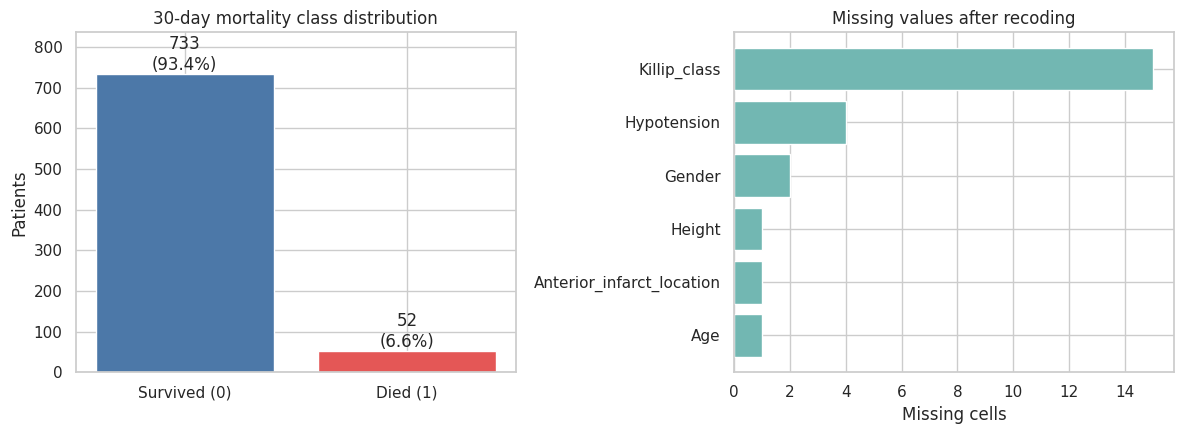

Figure saved: /kaggle/working/ISDS/outputs/figures/figure_01_outcome_and_missingness.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

outcome_counts = data[OUTCOME].value_counts().sort_index()
axes[0].bar(["Survived (0)", "Died (1)"], outcome_counts.values, color=["#4C78A8", "#E45756"])
axes[0].set_title("30-day mortality class distribution")
axes[0].set_ylabel("Patients")
for index, value in enumerate(outcome_counts.values):
    axes[0].text(index, value + 10, f"{value}\n({value/len(data):.1%})", ha="center")
axes[0].set_ylim(0, outcome_counts.max() * 1.14)

if not missingness.empty:
    plot_missingness = missingness.sort_values("missing_count")
    axes[1].barh(plot_missingness.index, plot_missingness["missing_count"], color="#72B7B2")
    axes[1].set_title("Missing values after recoding")
    axes[1].set_xlabel("Missing cells")
else:
    axes[1].text(0.5, 0.5, "No missing values", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
audit_figure_path = FIGURE_DIR / "figure_01_outcome_and_missingness.png"
fig.savefig(audit_figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure saved: {audit_figure_path}")

### 5.2 Key numerical checks

In [12]:
key_results = pd.Series({
    "patients": len(data),
    "candidate_predictors": len([c for c in data.columns if c != OUTCOME]),
    "deaths": int(data[OUTCOME].sum()),
    "event_rate_percent": 100 * data[OUTCOME].mean(),
    "non_events_per_event": (len(data) - data[OUTCOME].sum()) / data[OUTCOME].sum(),
    "events_per_candidate_predictor": data[OUTCOME].sum() / (data.shape[1] - 1),
    "processed_missing_cells": int(data.isna().sum().sum()),
    "exact_duplicate_rows": int(data.duplicated().sum()),
}, name="value").to_frame()

display(key_results.round(3))
assert int(key_results.loc["processed_missing_cells", "value"]) == 24
assert int(key_results.loc["exact_duplicate_rows", "value"]) == 0
print("INITIAL AUDIT COMPLETE")

,value
patients,785.000
candidate_predictors,17.000
deaths,52.000
event_rate_percent,6.624
non_events_per_event,14.096
events_per_candidate_predictor,3.059
processed_missing_cells,24.000
exact_duplicate_rows,0.000


INITIAL AUDIT COMPLETE


### 5.3 Interpretation

1. **Class imbalance is material:** only 52 of 785 patients died within 30 days. Accuracy would therefore reward a model that mostly predicts survival and is not an adequate primary metric.
2. **Overfitting risk is high:** 52 events across 17 candidate predictors gives approximately 3.06 events per predictor before considering nonlinearities or dummy variables.
3. **A single holdout split is inefficient:** a 20% test set would contain only about ten deaths on average, producing unstable estimates.
4. **Preprocessing leakage must be prevented:** imputation, scaling, feature selection, resampling, and tuning will all be fitted within training folds.
5. **Killip class needs care:** class 4 is extremely sparse; its ordinal treatment will be primary, with a categorical sensitivity analysis.

These are data-development findings, not claims of clinical transportability. The assignment provides no external validation dataset.

## 6. Pre-specified modelling protocol

The modelling workflow was fixed before final model selection:

1. Preserve the raw data and apply only auditable cleaning corrections.
2. Treat missing values inside model-training folds using median imputation for continuous/ordinal predictors and most-frequent imputation for binary/categorical predictors.
3. Standardise continuous/ordinal predictors inside the same pipeline and one-hot encode smoking status.
4. Use repeated stratified nested cross-validation for internal validation and hyperparameter tuning.
5. Evaluate penalised logistic regression and benchmark models using log loss for tuning, with ROC-AUC, PR-AUC, Brier score, log loss, and calibration for assessment.
6. Investigate class imbalance through matched no-rebalancing, class-weighting, and random-oversampling analyses.
7. Perform sensitivity analyses for Killip-class coding and missingness indicators.
8. Assess threshold-based classification behaviour, decision-curve net benefit, and outer-fold permutation importance.
9. Interpret model coefficients as predictive associations only; no causal claims are made.


## 7. Reporting and reproducibility notes

- The notebook is designed to run in a fresh Kaggle session with input data read from the Kaggle dataset mount and outputs written to `/kaggle/working/ISDS`.
- Only successful final analysis cells and relevant integrity checks are retained.
- Reported performance is based on internal validation; no external validation dataset was available.
- The report follows the official Option A requirements and uses TRIPOD elements 8-20 as a reporting guide.
- The complete executed notebook is preserved as the computational record, while the report appendix contains the core analysis source code.


## 8. Model development


### 8.1 Predictors and leakage-safe preprocessing


In [13]:
# ============================================================
# 9.1 Define predictors and leakage-safe preprocessing
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone

# ------------------------------------------------------------
# Outcome and predictors
# ------------------------------------------------------------
X = data.drop(columns=[OUTCOME]).copy()
y = data[OUTCOME].astype(int).copy()

# ------------------------------------------------------------
# Pre-specified feature groups
# ------------------------------------------------------------

# Continuous variables + Killip treated as ordinal in the
# primary analysis
continuous_ordinal_features = [
    "Age",
    "Killip_class",
    "Height",
    "Weight",
    "ST_elevation_leads",
]

# Binary 0/1 variables
binary_features = [
    "Gender",
    "Diabetes",
    "Hypotension",
    "Heart_rate",
    "Anterior_infarct_location",
    "Previous_myocardial_infarction",
    "Hypertension",
    "Hypercholesterolaemia",
    "Previous_angina_pectoris",
    "Family_history_of_MI",
    "Time_To_Relief",
]

# Nominal categorical variable
categorical_features = [
    "Smoking",
]

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
all_model_features = (
    continuous_ordinal_features
    + binary_features
    + categorical_features
)

assert len(all_model_features) == 17
assert len(set(all_model_features)) == 17
assert set(all_model_features) == set(X.columns)
assert len(X) == len(y) == 785
assert int(y.sum()) == 52

# ------------------------------------------------------------
# Preprocessing pipelines
#
# IMPORTANT:
# Nothing is imputed or scaled here globally.
# These operations will be fitted only on training folds when
# the preprocessing object is placed inside each model pipeline.
# ------------------------------------------------------------

continuous_ordinal_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

binary_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous_ordinal",
            continuous_ordinal_pipeline,
            continuous_ordinal_features,
        ),
        (
            "binary",
            binary_pipeline,
            binary_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# ------------------------------------------------------------
# Display modelling setup
# ------------------------------------------------------------

feature_setup = pd.DataFrame(
    {
        "feature_group": [
            "Continuous / ordinal",
            "Binary",
            "Categorical",
        ],
        "n_features": [
            len(continuous_ordinal_features),
            len(binary_features),
            len(categorical_features),
        ],
        "features": [
            ", ".join(continuous_ordinal_features),
            ", ".join(binary_features),
            ", ".join(categorical_features),
        ],
    }
)

display(feature_setup)

print("MODEL PREPARATION CHECK PASSED")
print(f"Patients: {len(X)}")
print(f"Candidate predictors: {X.shape[1]}")
print(f"Deaths: {int(y.sum())}")
print(f"Event rate: {y.mean():.2%}")
print(f"Survivors: {int((y == 0).sum())}")

print("\nMissing predictor cells before fold-specific imputation:")
display(
    X.isna()
    .sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)

print(
    "\nNo preprocessing has been fitted to the complete dataset."
    "\nImputation, scaling and encoding remain inside the pipeline."
)

,feature_group,n_features,features
0,Continuous / ordinal,5,"Age, Killip_class, Height, Weight, ST_elevatio..."
1,Binary,11,"Gender, Diabetes, Hypotension, Heart_rate, Ant..."
2,Categorical,1,Smoking


MODEL PREPARATION CHECK PASSED
Patients: 785
Candidate predictors: 17
Deaths: 52
Event rate: 6.62%
Survivors: 733

Missing predictor cells before fold-specific imputation:


,missing_count
Killip_class,15
Hypotension,4
Gender,2
Age,1
Anterior_infarct_location,1
Height,1



No preprocessing has been fitted to the complete dataset.
Imputation, scaling and encoding remain inside the pipeline.


### 8.2 Penalised logistic candidate model


In [16]:
# ============================================================
# 9.2 Primary model
# Elastic-net logistic regression with nested repeated CV
# Condition A: NO class rebalancing
# ============================================================

from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
)

# ------------------------------------------------------------
# Validation design
# ------------------------------------------------------------

OUTER_SPLITS = 5
OUTER_REPEATS = 5
INNER_SPLITS = 4

outer_cv = RepeatedStratifiedKFold(
    n_splits=OUTER_SPLITS,
    n_repeats=OUTER_REPEATS,
    random_state=RANDOM_SEED,
)

print("VALIDATION DESIGN")
print(
    f"Outer CV: {OUTER_SPLITS}-fold stratified CV "
    f"x {OUTER_REPEATS} repeats"
)
print(
    f"Total outer test folds: "
    f"{OUTER_SPLITS * OUTER_REPEATS}"
)
print(f"Inner CV: {INNER_SPLITS}-fold stratified CV")
print("Tuning criterion: log loss")
print()

# ------------------------------------------------------------
# Elastic-net model pipeline
#
# max_iter increased and tolerance relaxed slightly
# to improve numerical convergence with SAGA.
# ------------------------------------------------------------

elastic_net_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor),
        ),
        (
            "model",
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                max_iter=100000,
                tol=1e-3,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

# ------------------------------------------------------------
# Stable hyperparameter grid
#
# C:
#   smaller C -> stronger regularisation
#   larger C  -> weaker regularisation
#
# Values 10 and 100 are deliberately excluded because
# they produced convergence instability in diagnostic runs.
#
# l1_ratio:
#   0.00 -> ridge end
#   1.00 -> lasso end
#   between -> elastic net
# ------------------------------------------------------------

param_grid = {
    "model__C": [
        0.01,
        0.1,
        1.0,
    ],
    "model__l1_ratio": [
        0.00,
        0.25,
        0.50,
        0.75,
        1.00,
    ],
}

print(
    "Hyperparameter combinations:",
    len(param_grid["model__C"])
    * len(param_grid["model__l1_ratio"]),
)
print()

# ------------------------------------------------------------
# Nested repeated cross-validation
# ------------------------------------------------------------

prediction_rows = []
tuning_rows = []

total_outer_folds = (
    OUTER_SPLITS * OUTER_REPEATS
)

for split_id, (train_idx, test_idx) in enumerate(
    outer_cv.split(X, y),
    start=1,
):

    repeat_number = (
        (split_id - 1) // OUTER_SPLITS
    ) + 1

    fold_number = (
        (split_id - 1) % OUTER_SPLITS
    ) + 1

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    # Inner CV is created only inside
    # the current outer training set
    inner_cv = StratifiedKFold(
        n_splits=INNER_SPLITS,
        shuffle=True,
        random_state=(
            RANDOM_SEED + split_id
        ),
    )

    search = GridSearchCV(
        estimator=clone(
            elastic_net_pipeline
        ),
        param_grid=param_grid,
        scoring="neg_log_loss",
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
        error_score="raise",
    )

    # Preprocessing and tuning occur
    # inside training data only
    search.fit(
        X_train,
        y_train,
    )

    predicted_probability = (
        search.predict_proba(
            X_test
        )[:, 1]
    )

    # Store genuine outer-fold predictions
    for (
        local_position,
        original_position,
    ) in enumerate(test_idx):

        prediction_rows.append(
            {
                "patient_index":
                    X.index[
                        original_position
                    ],
                "repeat":
                    repeat_number,
                "fold":
                    fold_number,
                "y_true":
                    int(
                        y_test.iloc[
                            local_position
                        ]
                    ),
                "predicted_probability":
                    float(
                        predicted_probability[
                            local_position
                        ]
                    ),
            }
        )

    # Store selected hyperparameters
    tuning_rows.append(
        {
            "repeat":
                repeat_number,
            "fold":
                fold_number,
            "best_C":
                search.best_params_[
                    "model__C"
                ],
            "best_l1_ratio":
                search.best_params_[
                    "model__l1_ratio"
                ],
            "inner_cv_log_loss":
                -search.best_score_,
            "training_deaths":
                int(y_train.sum()),
            "test_deaths":
                int(y_test.sum()),
        }
    )

    print(
        f"Outer fold "
        f"{split_id:02d}/"
        f"{total_outer_folds} complete | "
        f"repeat={repeat_number}, "
        f"fold={fold_number} | "
        f"best C="
        f"{search.best_params_['model__C']} | "
        f"best l1_ratio="
        f"{search.best_params_['model__l1_ratio']}"
    )

print(
    "\nNESTED CV COMPLETE"
)

# ------------------------------------------------------------
# Convert results
# ------------------------------------------------------------

repeated_oof = pd.DataFrame(
    prediction_rows
)

tuning_results = pd.DataFrame(
    tuning_rows
)

# Each patient receives one OOF prediction
# in each repeat. Average across repeats.
oof_predictions = (
    repeated_oof
    .groupby(
        "patient_index",
        as_index=False,
    )
    .agg(
        y_true=(
            "y_true",
            "first",
        ),
        predicted_probability=(
            "predicted_probability",
            "mean",
        ),
        n_oof_predictions=(
            "predicted_probability",
            "size",
        ),
    )
)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

assert len(
    oof_predictions
) == len(X)

assert (
    oof_predictions[
        "n_oof_predictions"
    ]
    .eq(
        OUTER_REPEATS
    )
    .all()
)

assert int(
    oof_predictions[
        "y_true"
    ].sum()
) == 52

print(
    "\nOOF PREDICTION CHECK PASSED"
)

print(
    f"Unique patients evaluated: "
    f"{len(oof_predictions)}"
)

print(
    "OOF predictions per patient:",
    int(
        oof_predictions[
            "n_oof_predictions"
        ].min()
    ),
)

print(
    "Deaths represented in OOF data:",
    int(
        oof_predictions[
            "y_true"
        ].sum()
    ),
)

# ------------------------------------------------------------
# Internally validated performance
# ------------------------------------------------------------

y_oof = (
    oof_predictions[
        "y_true"
    ]
    .to_numpy()
)

p_oof = (
    oof_predictions[
        "predicted_probability"
    ]
    .to_numpy()
)

initial_metrics = pd.DataFrame(
    {
        "metric": [
            "ROC-AUC",
            "PR-AUC (average precision)",
            "Brier score",
            "Log loss",
        ],
        "value": [
            roc_auc_score(
                y_oof,
                p_oof,
            ),
            average_precision_score(
                y_oof,
                p_oof,
            ),
            brier_score_loss(
                y_oof,
                p_oof,
            ),
            log_loss(
                y_oof,
                p_oof,
            ),
        ],
    }
)

print(
    "\nINITIAL INTERNALLY "
    "VALIDATED PERFORMANCE"
)

display(
    initial_metrics.round(4)
)

# ------------------------------------------------------------
# Hyperparameter selection frequency
# ------------------------------------------------------------

tuning_frequency = (
    tuning_results
    .groupby(
        [
            "best_C",
            "best_l1_ratio",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size":
                "outer_folds_selected"
        }
    )
    .sort_values(
        "outer_folds_selected",
        ascending=False,
    )
)

print(
    "\nSELECTED "
    "HYPERPARAMETER FREQUENCY"
)

display(
    tuning_frequency
)

print(
    "\nOUTER-FOLD TUNING RESULTS"
)

display(
    tuning_results
)

# ------------------------------------------------------------
# Save reproducible Kaggle results
# ------------------------------------------------------------

repeated_oof_path = (
    TABLE_DIR
    / "elastic_net_no_rebalancing_repeated_oof.csv"
)

patient_oof_path = (
    TABLE_DIR
    / "elastic_net_no_rebalancing_patient_oof.csv"
)

tuning_path = (
    TABLE_DIR
    / "elastic_net_no_rebalancing_tuning.csv"
)

metrics_path = (
    TABLE_DIR
    / "elastic_net_no_rebalancing_initial_metrics.csv"
)

repeated_oof.to_csv(
    repeated_oof_path,
    index=False,
)

oof_predictions.to_csv(
    patient_oof_path,
    index=False,
)

tuning_results.to_csv(
    tuning_path,
    index=False,
)

initial_metrics.to_csv(
    metrics_path,
    index=False,
)

print(
    "\nRESULT FILES SAVED"
)

print(
    repeated_oof_path
)

print(
    patient_oof_path
)

print(
    tuning_path
)

print(
    metrics_path
)

VALIDATION DESIGN
Outer CV: 5-fold stratified CV x 5 repeats
Total outer test folds: 25
Inner CV: 4-fold stratified CV
Tuning criterion: log loss

Hyperparameter combinations: 15

Outer fold 01/25 complete | repeat=1, fold=1 | best C=1.0 | best l1_ratio=0.0
Outer fold 02/25 complete | repeat=1, fold=2 | best C=0.1 | best l1_ratio=0.0
Outer fold 03/25 complete | repeat=1, fold=3 | best C=0.1 | best l1_ratio=0.0
Outer fold 04/25 complete | repeat=1, fold=4 | best C=0.1 | best l1_ratio=0.0
Outer fold 05/25 complete | repeat=1, fold=5 | best C=0.1 | best l1_ratio=0.0
Outer fold 06/25 complete | repeat=2, fold=1 | best C=0.1 | best l1_ratio=0.0
Outer fold 07/25 complete | repeat=2, fold=2 | best C=1.0 | best l1_ratio=1.0
Outer fold 08/25 complete | repeat=2, fold=3 | best C=0.1 | best l1_ratio=0.0
Outer fold 09/25 complete | repeat=2, fold=4 | best C=0.1 | best l1_ratio=0.0
Outer fold 10/25 complete | repeat=2, fold=5 | best C=0.1 | best l1_ratio=0.0
Outer fold 11/25 complete | repeat=3, fo

,metric,value
0,ROC-AUC,0.7878
1,PR-AUC (average precision),0.2790
2,Brier score,0.0556
3,Log loss,0.2071



SELECTED HYPERPARAMETER FREQUENCY


,best_C,best_l1_ratio,outer_folds_selected
0,0.1,0.00,20
3,1.0,0.75,2
1,0.1,0.25,1
2,1.0,0.00,1
4,1.0,1.00,1



OUTER-FOLD TUNING RESULTS


,repeat,fold,best_C,best_l1_ratio,inner_cv_log_loss,training_deaths,test_deaths
0,1,1,1.0,0.00,0.198226,42,10
1,1,2,0.1,0.00,0.204277,42,10
2,1,3,0.1,0.00,0.217943,42,10
3,1,4,0.1,0.00,0.206963,41,11
4,1,5,0.1,0.00,0.213693,41,11
5,2,1,0.1,0.00,0.208085,42,10
6,2,2,1.0,1.00,0.204269,42,10
7,2,3,0.1,0.00,0.218646,42,10
8,2,4,0.1,0.00,0.208291,41,11
9,2,5,0.1,0.00,0.200031,41,11



RESULT FILES SAVED
/kaggle/working/ISDS/outputs/tables/elastic_net_no_rebalancing_repeated_oof.csv
/kaggle/working/ISDS/outputs/tables/elastic_net_no_rebalancing_patient_oof.csv
/kaggle/working/ISDS/outputs/tables/elastic_net_no_rebalancing_tuning.csv
/kaggle/working/ISDS/outputs/tables/elastic_net_no_rebalancing_initial_metrics.csv


**Model-development note.** The penalised logistic search allowed the L1/L2 mixing parameter to vary inside the inner cross-validation loop. The selected solutions were overwhelmingly at the ridge/L2 end of the elastic-net path. A numerically stable ridge specification was therefore used for matched class-imbalance experiments and retained as the final penalised logistic model.


### 8.3 Ridge logistic regression without rebalancing


In [18]:
# ============================================================
# 9.3A Matched imbalance reference
# Ridge logistic regression — NO REBALANCING
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
)

# ------------------------------------------------------------
# Ridge model
#
# L2 penalty + lbfgs is numerically much more stable than
# SAGA elastic-net for this small, imbalanced dataset.
# ------------------------------------------------------------

ridge_none_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor),
        ),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                class_weight=None,
                max_iter=20000,
                tol=1e-4,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

# Same C grid will also be used for the weighted model
ridge_param_grid = {
    "model__C": [
        0.01,
        0.1,
        1.0,
    ]
}

ridge_none_prediction_rows = []
ridge_none_tuning_rows = []

print("RUNNING RIDGE LOGISTIC — NO REBALANCING")
print(
    f"Outer validation: {OUTER_SPLITS}-fold x "
    f"{OUTER_REPEATS} repeats"
)
print(f"Inner validation: {INNER_SPLITS}-fold")
print("Penalty: L2 / ridge")
print("Solver: lbfgs")
print("Class weighting: None")
print("Tuning criterion: log loss")
print()

# ------------------------------------------------------------
# Same outer CV design used previously
# ------------------------------------------------------------

for split_id, (train_idx, test_idx) in enumerate(
    outer_cv.split(X, y),
    start=1,
):

    repeat_number = ((split_id - 1) // OUTER_SPLITS) + 1
    fold_number = ((split_id - 1) % OUTER_SPLITS) + 1

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    inner_cv = StratifiedKFold(
        n_splits=INNER_SPLITS,
        shuffle=True,
        random_state=RANDOM_SEED + split_id,
    )

    search = GridSearchCV(
        estimator=clone(ridge_none_pipeline),
        param_grid=ridge_param_grid,
        scoring="neg_log_loss",
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
        error_score="raise",
    )

    search.fit(
        X_train,
        y_train,
    )

    predicted_probability = (
        search.predict_proba(X_test)[:, 1]
    )

    # Genuine outer-fold predictions
    for local_position, original_position in enumerate(
        test_idx
    ):

        ridge_none_prediction_rows.append(
            {
                "patient_index":
                    X.index[original_position],
                "repeat":
                    repeat_number,
                "fold":
                    fold_number,
                "y_true":
                    int(
                        y_test.iloc[local_position]
                    ),
                "predicted_probability":
                    float(
                        predicted_probability[
                            local_position
                        ]
                    ),
            }
        )

    ridge_none_tuning_rows.append(
        {
            "repeat":
                repeat_number,
            "fold":
                fold_number,
            "best_C":
                search.best_params_[
                    "model__C"
                ],
            "inner_cv_log_loss":
                -search.best_score_,
            "training_deaths":
                int(y_train.sum()),
            "test_deaths":
                int(y_test.sum()),
        }
    )

    print(
        f"Outer fold {split_id:02d}/"
        f"{total_outer_folds} complete | "
        f"repeat={repeat_number}, "
        f"fold={fold_number} | "
        f"best C="
        f"{search.best_params_['model__C']}"
    )

print("\nRIDGE NO-REBALANCING NESTED CV COMPLETE")

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

ridge_none_repeated_oof = pd.DataFrame(
    ridge_none_prediction_rows
)

ridge_none_tuning_results = pd.DataFrame(
    ridge_none_tuning_rows
)

ridge_none_oof = (
    ridge_none_repeated_oof
    .groupby(
        "patient_index",
        as_index=False,
    )
    .agg(
        y_true=(
            "y_true",
            "first",
        ),
        predicted_probability=(
            "predicted_probability",
            "mean",
        ),
        n_oof_predictions=(
            "predicted_probability",
            "size",
        ),
    )
)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

assert len(ridge_none_oof) == len(X)

assert (
    ridge_none_oof[
        "n_oof_predictions"
    ]
    .eq(OUTER_REPEATS)
    .all()
)

assert int(
    ridge_none_oof[
        "y_true"
    ].sum()
) == 52

print("\nRIDGE NO-REBALANCING OOF CHECK PASSED")
print(
    "Unique patients evaluated:",
    len(ridge_none_oof),
)
print(
    "OOF predictions per patient:",
    int(
        ridge_none_oof[
            "n_oof_predictions"
        ].min()
    ),
)
print(
    "Deaths represented:",
    int(
        ridge_none_oof[
            "y_true"
        ].sum()
    ),
)

# ------------------------------------------------------------
# Performance
# ------------------------------------------------------------

y_ridge_none = (
    ridge_none_oof[
        "y_true"
    ].to_numpy()
)

p_ridge_none = (
    ridge_none_oof[
        "predicted_probability"
    ].to_numpy()
)

ridge_none_metrics = pd.DataFrame(
    {
        "metric": [
            "ROC-AUC",
            "PR-AUC (average precision)",
            "Brier score",
            "Log loss",
        ],
        "value": [
            roc_auc_score(
                y_ridge_none,
                p_ridge_none,
            ),
            average_precision_score(
                y_ridge_none,
                p_ridge_none,
            ),
            brier_score_loss(
                y_ridge_none,
                p_ridge_none,
            ),
            log_loss(
                y_ridge_none,
                p_ridge_none,
            ),
        ],
    }
)

print(
    "\nRIDGE NO-REBALANCING "
    "INTERNALLY VALIDATED PERFORMANCE"
)

display(
    ridge_none_metrics.round(4)
)

# ------------------------------------------------------------
# Hyperparameter frequency
# ------------------------------------------------------------

ridge_none_tuning_frequency = (
    ridge_none_tuning_results
    .groupby(
        "best_C",
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size":
                "outer_folds_selected"
        }
    )
    .sort_values(
        "outer_folds_selected",
        ascending=False,
    )
)

print(
    "\nRIDGE NO-REBALANCING "
    "HYPERPARAMETER FREQUENCY"
)

display(
    ridge_none_tuning_frequency
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

ridge_none_repeated_oof.to_csv(
    TABLE_DIR
    / "ridge_no_rebalancing_repeated_oof.csv",
    index=False,
)

ridge_none_oof.to_csv(
    TABLE_DIR
    / "ridge_no_rebalancing_patient_oof.csv",
    index=False,
)

ridge_none_tuning_results.to_csv(
    TABLE_DIR
    / "ridge_no_rebalancing_tuning.csv",
    index=False,
)

ridge_none_metrics.to_csv(
    TABLE_DIR
    / "ridge_no_rebalancing_metrics.csv",
    index=False,
)

print(
    "\nRIDGE NO-REBALANCING RESULT FILES SAVED"
)

RUNNING RIDGE LOGISTIC — NO REBALANCING
Outer validation: 5-fold x 5 repeats
Inner validation: 4-fold
Penalty: L2 / ridge
Solver: lbfgs
Class weighting: None
Tuning criterion: log loss

Outer fold 01/25 complete | repeat=1, fold=1 | best C=1.0
Outer fold 02/25 complete | repeat=1, fold=2 | best C=0.1
Outer fold 03/25 complete | repeat=1, fold=3 | best C=0.1
Outer fold 04/25 complete | repeat=1, fold=4 | best C=0.1
Outer fold 05/25 complete | repeat=1, fold=5 | best C=0.1
Outer fold 06/25 complete | repeat=2, fold=1 | best C=0.1
Outer fold 07/25 complete | repeat=2, fold=2 | best C=1.0
Outer fold 08/25 complete | repeat=2, fold=3 | best C=0.1
Outer fold 09/25 complete | repeat=2, fold=4 | best C=0.1
Outer fold 10/25 complete | repeat=2, fold=5 | best C=0.1
Outer fold 11/25 complete | repeat=3, fold=1 | best C=0.1
Outer fold 12/25 complete | repeat=3, fold=2 | best C=0.1
Outer fold 13/25 complete | repeat=3, fold=3 | best C=0.1
Outer fold 14/25 complete | repeat=3, fold=4 | best C=0.1
Ou

,metric,value
0,ROC-AUC,0.7881
1,PR-AUC (average precision),0.2783
2,Brier score,0.0556
3,Log loss,0.2070



RIDGE NO-REBALANCING HYPERPARAMETER FREQUENCY


,best_C,outer_folds_selected
0,0.1,22
1,1.0,3



RIDGE NO-REBALANCING RESULT FILES SAVED


### 8.4 Ridge logistic regression with class weighting


In [19]:
# ============================================================
# 9.3B Class-imbalance ablation
# Ridge logistic regression — CLASS WEIGHTING
# ============================================================

# ------------------------------------------------------------
# Exactly the same model family, preprocessing,
# C-grid and validation as 9.3A.
#
# ONLY substantive change:
# class_weight=None  ->  class_weight="balanced"
# ------------------------------------------------------------

ridge_weighted_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor),
        ),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                class_weight="balanced",
                max_iter=20000,
                tol=1e-4,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

ridge_weighted_prediction_rows = []
ridge_weighted_tuning_rows = []

print("RUNNING RIDGE LOGISTIC — CLASS WEIGHTED")
print(
    f"Outer validation: {OUTER_SPLITS}-fold x "
    f"{OUTER_REPEATS} repeats"
)
print(f"Inner validation: {INNER_SPLITS}-fold")
print("Penalty: L2 / ridge")
print("Solver: lbfgs")
print("Class weighting: balanced")
print("Tuning criterion: log loss")
print()

# ------------------------------------------------------------
# Same nested CV design
# ------------------------------------------------------------

for split_id, (train_idx, test_idx) in enumerate(
    outer_cv.split(X, y),
    start=1,
):

    repeat_number = ((split_id - 1) // OUTER_SPLITS) + 1
    fold_number = ((split_id - 1) % OUTER_SPLITS) + 1

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    inner_cv = StratifiedKFold(
        n_splits=INNER_SPLITS,
        shuffle=True,
        random_state=RANDOM_SEED + split_id,
    )

    search = GridSearchCV(
        estimator=clone(ridge_weighted_pipeline),
        param_grid=ridge_param_grid,
        scoring="neg_log_loss",
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
        error_score="raise",
    )

    search.fit(
        X_train,
        y_train,
    )

    predicted_probability = (
        search.predict_proba(X_test)[:, 1]
    )

    # Genuine outer-fold predictions
    for local_position, original_position in enumerate(
        test_idx
    ):

        ridge_weighted_prediction_rows.append(
            {
                "patient_index":
                    X.index[original_position],
                "repeat":
                    repeat_number,
                "fold":
                    fold_number,
                "y_true":
                    int(
                        y_test.iloc[
                            local_position
                        ]
                    ),
                "predicted_probability":
                    float(
                        predicted_probability[
                            local_position
                        ]
                    ),
            }
        )

    ridge_weighted_tuning_rows.append(
        {
            "repeat":
                repeat_number,
            "fold":
                fold_number,
            "best_C":
                search.best_params_[
                    "model__C"
                ],
            "inner_cv_log_loss":
                -search.best_score_,
            "training_deaths":
                int(y_train.sum()),
            "test_deaths":
                int(y_test.sum()),
        }
    )

    print(
        f"Outer fold {split_id:02d}/"
        f"{total_outer_folds} complete | "
        f"repeat={repeat_number}, "
        f"fold={fold_number} | "
        f"best C="
        f"{search.best_params_['model__C']}"
    )

print(
    "\nRIDGE CLASS-WEIGHTED NESTED CV COMPLETE"
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

ridge_weighted_repeated_oof = pd.DataFrame(
    ridge_weighted_prediction_rows
)

ridge_weighted_tuning_results = pd.DataFrame(
    ridge_weighted_tuning_rows
)

ridge_weighted_oof = (
    ridge_weighted_repeated_oof
    .groupby(
        "patient_index",
        as_index=False,
    )
    .agg(
        y_true=(
            "y_true",
            "first",
        ),
        predicted_probability=(
            "predicted_probability",
            "mean",
        ),
        n_oof_predictions=(
            "predicted_probability",
            "size",
        ),
    )
)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

assert len(
    ridge_weighted_oof
) == len(X)

assert (
    ridge_weighted_oof[
        "n_oof_predictions"
    ]
    .eq(OUTER_REPEATS)
    .all()
)

assert int(
    ridge_weighted_oof[
        "y_true"
    ].sum()
) == 52

print(
    "\nRIDGE CLASS-WEIGHTED OOF CHECK PASSED"
)

print(
    "Unique patients evaluated:",
    len(ridge_weighted_oof),
)

print(
    "OOF predictions per patient:",
    int(
        ridge_weighted_oof[
            "n_oof_predictions"
        ].min()
    ),
)

print(
    "Deaths represented:",
    int(
        ridge_weighted_oof[
            "y_true"
        ].sum()
    ),
)

# ------------------------------------------------------------
# Performance
# ------------------------------------------------------------

y_ridge_weighted = (
    ridge_weighted_oof[
        "y_true"
    ].to_numpy()
)

p_ridge_weighted = (
    ridge_weighted_oof[
        "predicted_probability"
    ].to_numpy()
)

ridge_weighted_metrics = pd.DataFrame(
    {
        "metric": [
            "ROC-AUC",
            "PR-AUC (average precision)",
            "Brier score",
            "Log loss",
        ],
        "value": [
            roc_auc_score(
                y_ridge_weighted,
                p_ridge_weighted,
            ),
            average_precision_score(
                y_ridge_weighted,
                p_ridge_weighted,
            ),
            brier_score_loss(
                y_ridge_weighted,
                p_ridge_weighted,
            ),
            log_loss(
                y_ridge_weighted,
                p_ridge_weighted,
            ),
        ],
    }
)

print(
    "\nRIDGE CLASS-WEIGHTED "
    "INTERNALLY VALIDATED PERFORMANCE"
)

display(
    ridge_weighted_metrics.round(4)
)

# ------------------------------------------------------------
# Hyperparameter frequency
# ------------------------------------------------------------

ridge_weighted_tuning_frequency = (
    ridge_weighted_tuning_results
    .groupby(
        "best_C",
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size":
                "outer_folds_selected"
        }
    )
    .sort_values(
        "outer_folds_selected",
        ascending=False,
    )
)

print(
    "\nRIDGE CLASS-WEIGHTED "
    "HYPERPARAMETER FREQUENCY"
)

display(
    ridge_weighted_tuning_frequency
)

# ------------------------------------------------------------
# Fair matched imbalance comparison
# ------------------------------------------------------------

ridge_A_B_comparison = (
    ridge_none_metrics
    .rename(
        columns={
            "value":
                "ridge_no_rebalancing"
        }
    )
    .merge(
        ridge_weighted_metrics.rename(
            columns={
                "value":
                    "ridge_class_weighted"
            }
        ),
        on="metric",
    )
)

ridge_A_B_comparison[
    "weighted_minus_none"
] = (
    ridge_A_B_comparison[
        "ridge_class_weighted"
    ]
    - ridge_A_B_comparison[
        "ridge_no_rebalancing"
    ]
)

print(
    "\nMATCHED RIDGE ABLATION: "
    "NO REBALANCING vs CLASS WEIGHTING"
)

display(
    ridge_A_B_comparison.round(4)
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

ridge_weighted_repeated_oof.to_csv(
    TABLE_DIR
    / "ridge_class_weighted_repeated_oof.csv",
    index=False,
)

ridge_weighted_oof.to_csv(
    TABLE_DIR
    / "ridge_class_weighted_patient_oof.csv",
    index=False,
)

ridge_weighted_tuning_results.to_csv(
    TABLE_DIR
    / "ridge_class_weighted_tuning.csv",
    index=False,
)

ridge_weighted_metrics.to_csv(
    TABLE_DIR
    / "ridge_class_weighted_metrics.csv",
    index=False,
)

ridge_A_B_comparison.to_csv(
    TABLE_DIR
    / "ridge_ablation_none_vs_class_weighted.csv",
    index=False,
)

print(
    "\nRIDGE CLASS-WEIGHTED RESULT FILES SAVED"
)

RUNNING RIDGE LOGISTIC — CLASS WEIGHTED
Outer validation: 5-fold x 5 repeats
Inner validation: 4-fold
Penalty: L2 / ridge
Solver: lbfgs
Class weighting: balanced
Tuning criterion: log loss

Outer fold 01/25 complete | repeat=1, fold=1 | best C=0.1
Outer fold 02/25 complete | repeat=1, fold=2 | best C=0.1
Outer fold 03/25 complete | repeat=1, fold=3 | best C=0.1
Outer fold 04/25 complete | repeat=1, fold=4 | best C=0.1
Outer fold 05/25 complete | repeat=1, fold=5 | best C=0.1
Outer fold 06/25 complete | repeat=2, fold=1 | best C=0.1
Outer fold 07/25 complete | repeat=2, fold=2 | best C=0.1
Outer fold 08/25 complete | repeat=2, fold=3 | best C=0.1
Outer fold 09/25 complete | repeat=2, fold=4 | best C=0.1
Outer fold 10/25 complete | repeat=2, fold=5 | best C=0.1
Outer fold 11/25 complete | repeat=3, fold=1 | best C=0.1
Outer fold 12/25 complete | repeat=3, fold=2 | best C=0.1
Outer fold 13/25 complete | repeat=3, fold=3 | best C=1.0
Outer fold 14/25 complete | repeat=3, fold=4 | best C=0.

,metric,value
0,ROC-AUC,0.7746
1,PR-AUC (average precision),0.2712
2,Brier score,0.1711
3,Log loss,0.5138



RIDGE CLASS-WEIGHTED HYPERPARAMETER FREQUENCY


,best_C,outer_folds_selected
0,0.1,24
1,1.0,1



MATCHED RIDGE ABLATION: NO REBALANCING vs CLASS WEIGHTING


,metric,ridge_no_rebalancing,ridge_class_weighted,weighted_minus_none
0,ROC-AUC,0.7881,0.7746,-0.0135
1,PR-AUC (average precision),0.2783,0.2712,-0.0071
2,Brier score,0.0556,0.1711,0.1155
3,Log loss,0.2070,0.5138,0.3068



RIDGE CLASS-WEIGHTED RESULT FILES SAVED


### 8.5 Ridge logistic regression with random oversampling


In [20]:
# ============================================================
# 9.4 Class-imbalance ablation
# Ridge logistic regression — RANDOM OVERSAMPLING
# ============================================================

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import RandomOverSampler

    print("imbalanced-learn imported successfully.")

except ImportError:
    raise ImportError(
        "imbalanced-learn is not available in this Kaggle runtime."
    )

# ------------------------------------------------------------
# Matched model design
#
# Same:
#   - preprocessing
#   - ridge/L2 penalty
#   - lbfgs solver
#   - C tuning grid
#   - nested CV
#
# Only change:
#   Random oversampling of the minority class
#   INSIDE each training fold.
#
# Validation and test folds are NEVER oversampled.
# ------------------------------------------------------------

ridge_oversampling_pipeline = ImbPipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor),
        ),
        (
            "oversampler",
            RandomOverSampler(
                sampling_strategy="auto",
                random_state=RANDOM_SEED,
            ),
        ),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                class_weight=None,
                max_iter=20000,
                tol=1e-4,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

ridge_oversampling_prediction_rows = []
ridge_oversampling_tuning_rows = []

print("\nRUNNING RIDGE LOGISTIC — RANDOM OVERSAMPLING")

print(
    f"Outer validation: "
    f"{OUTER_SPLITS}-fold x "
    f"{OUTER_REPEATS} repeats"
)

print(
    f"Inner validation: "
    f"{INNER_SPLITS}-fold"
)

print("Penalty: L2 / ridge")
print("Solver: lbfgs")
print("Class weighting: None")
print("Oversampling: RandomOverSampler")
print("Tuning criterion: log loss")
print()

# ------------------------------------------------------------
# Same nested CV design
# ------------------------------------------------------------

for split_id, (train_idx, test_idx) in enumerate(
    outer_cv.split(X, y),
    start=1,
):

    repeat_number = (
        (split_id - 1) // OUTER_SPLITS
    ) + 1

    fold_number = (
        (split_id - 1) % OUTER_SPLITS
    ) + 1

    X_train = X.iloc[
        train_idx
    ]

    y_train = y.iloc[
        train_idx
    ]

    X_test = X.iloc[
        test_idx
    ]

    y_test = y.iloc[
        test_idx
    ]

    inner_cv = StratifiedKFold(
        n_splits=INNER_SPLITS,
        shuffle=True,
        random_state=(
            RANDOM_SEED + split_id
        ),
    )

    search = GridSearchCV(
        estimator=clone(
            ridge_oversampling_pipeline
        ),
        param_grid=ridge_param_grid,
        scoring="neg_log_loss",
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
        error_score="raise",
    )

    search.fit(
        X_train,
        y_train,
    )

    predicted_probability = (
        search.predict_proba(
            X_test
        )[:, 1]
    )

    # --------------------------------------------------------
    # Store genuine outer-fold predictions
    # --------------------------------------------------------

    for (
        local_position,
        original_position,
    ) in enumerate(
        test_idx
    ):

        ridge_oversampling_prediction_rows.append(
            {
                "patient_index":
                    X.index[
                        original_position
                    ],
                "repeat":
                    repeat_number,
                "fold":
                    fold_number,
                "y_true":
                    int(
                        y_test.iloc[
                            local_position
                        ]
                    ),
                "predicted_probability":
                    float(
                        predicted_probability[
                            local_position
                        ]
                    ),
            }
        )

    ridge_oversampling_tuning_rows.append(
        {
            "repeat":
                repeat_number,
            "fold":
                fold_number,
            "best_C":
                search.best_params_[
                    "model__C"
                ],
            "inner_cv_log_loss":
                -search.best_score_,
            "training_deaths":
                int(
                    y_train.sum()
                ),
            "test_deaths":
                int(
                    y_test.sum()
                ),
        }
    )

    print(
        f"Outer fold "
        f"{split_id:02d}/"
        f"{total_outer_folds} complete | "
        f"repeat={repeat_number}, "
        f"fold={fold_number} | "
        f"best C="
        f"{search.best_params_['model__C']}"
    )

print(
    "\nRIDGE RANDOM-OVERSAMPLING "
    "NESTED CV COMPLETE"
)

# ------------------------------------------------------------
# Convert results
# ------------------------------------------------------------

ridge_oversampling_repeated_oof = pd.DataFrame(
    ridge_oversampling_prediction_rows
)

ridge_oversampling_tuning_results = pd.DataFrame(
    ridge_oversampling_tuning_rows
)

ridge_oversampling_oof = (
    ridge_oversampling_repeated_oof
    .groupby(
        "patient_index",
        as_index=False,
    )
    .agg(
        y_true=(
            "y_true",
            "first",
        ),
        predicted_probability=(
            "predicted_probability",
            "mean",
        ),
        n_oof_predictions=(
            "predicted_probability",
            "size",
        ),
    )
)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

assert len(
    ridge_oversampling_oof
) == len(X)

assert (
    ridge_oversampling_oof[
        "n_oof_predictions"
    ]
    .eq(
        OUTER_REPEATS
    )
    .all()
)

assert int(
    ridge_oversampling_oof[
        "y_true"
    ].sum()
) == 52

print(
    "\nRIDGE RANDOM-OVERSAMPLING "
    "OOF CHECK PASSED"
)

print(
    "Unique patients evaluated:",
    len(
        ridge_oversampling_oof
    ),
)

print(
    "OOF predictions per patient:",
    int(
        ridge_oversampling_oof[
            "n_oof_predictions"
        ].min()
    ),
)

print(
    "Deaths represented:",
    int(
        ridge_oversampling_oof[
            "y_true"
        ].sum()
    ),
)

# ------------------------------------------------------------
# Performance
# ------------------------------------------------------------

y_ridge_over = (
    ridge_oversampling_oof[
        "y_true"
    ]
    .to_numpy()
)

p_ridge_over = (
    ridge_oversampling_oof[
        "predicted_probability"
    ]
    .to_numpy()
)

ridge_oversampling_metrics = pd.DataFrame(
    {
        "metric": [
            "ROC-AUC",
            "PR-AUC (average precision)",
            "Brier score",
            "Log loss",
        ],
        "value": [
            roc_auc_score(
                y_ridge_over,
                p_ridge_over,
            ),
            average_precision_score(
                y_ridge_over,
                p_ridge_over,
            ),
            brier_score_loss(
                y_ridge_over,
                p_ridge_over,
            ),
            log_loss(
                y_ridge_over,
                p_ridge_over,
            ),
        ],
    }
)

print(
    "\nRIDGE RANDOM-OVERSAMPLING "
    "INTERNALLY VALIDATED PERFORMANCE"
)

display(
    ridge_oversampling_metrics.round(4)
)

# ------------------------------------------------------------
# Hyperparameter frequency
# ------------------------------------------------------------

ridge_oversampling_tuning_frequency = (
    ridge_oversampling_tuning_results
    .groupby(
        "best_C",
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size":
                "outer_folds_selected"
        }
    )
    .sort_values(
        "outer_folds_selected",
        ascending=False,
    )
)

print(
    "\nRIDGE RANDOM-OVERSAMPLING "
    "HYPERPARAMETER FREQUENCY"
)

display(
    ridge_oversampling_tuning_frequency
)

# ------------------------------------------------------------
# Full matched imbalance ablation:
# A = no rebalancing
# B = class weighting
# C = random oversampling
# ------------------------------------------------------------

ridge_A_B_C_comparison = (
    ridge_none_metrics
    .rename(
        columns={
            "value":
                "no_rebalancing"
        }
    )
    .merge(
        ridge_weighted_metrics.rename(
            columns={
                "value":
                    "class_weighted"
            }
        ),
        on="metric",
    )
    .merge(
        ridge_oversampling_metrics.rename(
            columns={
                "value":
                    "random_oversampling"
            }
        ),
        on="metric",
    )
)

print(
    "\nFULL MATCHED RIDGE IMBALANCE ABLATION"
)

display(
    ridge_A_B_C_comparison.round(4)
)

# ------------------------------------------------------------
# Difference relative to no rebalancing
# ------------------------------------------------------------

ridge_ablation_differences = (
    ridge_A_B_C_comparison.copy()
)

ridge_ablation_differences[
    "weighted_minus_none"
] = (
    ridge_ablation_differences[
        "class_weighted"
    ]
    - ridge_ablation_differences[
        "no_rebalancing"
    ]
)

ridge_ablation_differences[
    "oversampling_minus_none"
] = (
    ridge_ablation_differences[
        "random_oversampling"
    ]
    - ridge_ablation_differences[
        "no_rebalancing"
    ]
)

print(
    "\nIMBALANCE ABLATION DIFFERENCES"
)

display(
    ridge_ablation_differences.round(4)
)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

ridge_oversampling_repeated_oof.to_csv(
    TABLE_DIR
    / "ridge_random_oversampling_repeated_oof.csv",
    index=False,
)

ridge_oversampling_oof.to_csv(
    TABLE_DIR
    / "ridge_random_oversampling_patient_oof.csv",
    index=False,
)

ridge_oversampling_tuning_results.to_csv(
    TABLE_DIR
    / "ridge_random_oversampling_tuning.csv",
    index=False,
)

ridge_oversampling_metrics.to_csv(
    TABLE_DIR
    / "ridge_random_oversampling_metrics.csv",
    index=False,
)

ridge_A_B_C_comparison.to_csv(
    TABLE_DIR
    / "ridge_full_imbalance_ablation.csv",
    index=False,
)

ridge_ablation_differences.to_csv(
    TABLE_DIR
    / "ridge_imbalance_ablation_differences.csv",
    index=False,
)

print(
    "\nRIDGE RANDOM-OVERSAMPLING "
    "RESULT FILES SAVED"
)

imbalanced-learn imported successfully.

RUNNING RIDGE LOGISTIC — RANDOM OVERSAMPLING
Outer validation: 5-fold x 5 repeats
Inner validation: 4-fold
Penalty: L2 / ridge
Solver: lbfgs
Class weighting: None
Oversampling: RandomOverSampler
Tuning criterion: log loss

Outer fold 01/25 complete | repeat=1, fold=1 | best C=0.1
Outer fold 02/25 complete | repeat=1, fold=2 | best C=0.1
Outer fold 03/25 complete | repeat=1, fold=3 | best C=0.1
Outer fold 04/25 complete | repeat=1, fold=4 | best C=0.1
Outer fold 05/25 complete | repeat=1, fold=5 | best C=0.1
Outer fold 06/25 complete | repeat=2, fold=1 | best C=0.1
Outer fold 07/25 complete | repeat=2, fold=2 | best C=0.1
Outer fold 08/25 complete | repeat=2, fold=3 | best C=0.1
Outer fold 09/25 complete | repeat=2, fold=4 | best C=0.1
Outer fold 10/25 complete | repeat=2, fold=5 | best C=0.1
Outer fold 11/25 complete | repeat=3, fold=1 | best C=0.1
Outer fold 12/25 complete | repeat=3, fold=2 | best C=0.1
Outer fold 13/25 complete | repeat=3, fo

,metric,value
0,ROC-AUC,0.7703
1,PR-AUC (average precision),0.2700
2,Brier score,0.1700
3,Log loss,0.5108



RIDGE RANDOM-OVERSAMPLING HYPERPARAMETER FREQUENCY


,best_C,outer_folds_selected
0,0.1,25



FULL MATCHED RIDGE IMBALANCE ABLATION


,metric,no_rebalancing,class_weighted,random_oversampling
0,ROC-AUC,0.7881,0.7746,0.7703
1,PR-AUC (average precision),0.2783,0.2712,0.2700
2,Brier score,0.0556,0.1711,0.1700
3,Log loss,0.2070,0.5138,0.5108



IMBALANCE ABLATION DIFFERENCES


,metric,no_rebalancing,class_weighted,random_oversampling,weighted_minus_none,oversampling_minus_none
0,ROC-AUC,0.7881,0.7746,0.7703,-0.0135,-0.0178
1,PR-AUC (average precision),0.2783,0.2712,0.2700,-0.0071,-0.0084
2,Brier score,0.0556,0.1711,0.1700,0.1155,0.1144
3,Log loss,0.2070,0.5138,0.5108,0.3068,0.3038



RIDGE RANDOM-OVERSAMPLING RESULT FILES SAVED


## 9. Benchmark models

### 9.1 Reusable evaluation framework


In [21]:
# ============================================================
# 10.1 Reusable benchmark evaluation framework
# ============================================================

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)

def evaluate_nested_model(
    model_name,
    pipeline,
    parameter_grid,
    file_prefix,
):
    """
    Evaluate one candidate prediction model using the same
    repeated nested CV design used in the primary analysis.

    All preprocessing and hyperparameter tuning occur inside
    training folds only.
    """

    prediction_rows = []
    tuning_rows = []

    print("=" * 70)
    print(f"RUNNING: {model_name}")
    print(
        f"Outer validation: "
        f"{OUTER_SPLITS}-fold x "
        f"{OUTER_REPEATS} repeats"
    )
    print(
        f"Inner validation: "
        f"{INNER_SPLITS}-fold"
    )
    print("Tuning criterion: log loss")
    print("Class rebalancing: None")
    print("=" * 70)
    print()

    for split_id, (train_idx, test_idx) in enumerate(
        outer_cv.split(X, y),
        start=1,
    ):

        repeat_number = (
            (split_id - 1)
            // OUTER_SPLITS
        ) + 1

        fold_number = (
            (split_id - 1)
            % OUTER_SPLITS
        ) + 1

        X_train = X.iloc[
            train_idx
        ]

        y_train = y.iloc[
            train_idx
        ]

        X_test = X.iloc[
            test_idx
        ]

        y_test = y.iloc[
            test_idx
        ]

        inner_cv = StratifiedKFold(
            n_splits=INNER_SPLITS,
            shuffle=True,
            random_state=(
                RANDOM_SEED
                + split_id
            ),
        )

        search = GridSearchCV(
            estimator=clone(
                pipeline
            ),
            param_grid=parameter_grid,
            scoring="neg_log_loss",
            cv=inner_cv,
            refit=True,
            n_jobs=-1,
            error_score="raise",
        )

        search.fit(
            X_train,
            y_train,
        )

        predicted_probability = (
            search.predict_proba(
                X_test
            )[:, 1]
        )

        for (
            local_position,
            original_position,
        ) in enumerate(
            test_idx
        ):

            prediction_rows.append(
                {
                    "patient_index":
                        X.index[
                            original_position
                        ],
                    "repeat":
                        repeat_number,
                    "fold":
                        fold_number,
                    "y_true":
                        int(
                            y_test.iloc[
                                local_position
                            ]
                        ),
                    "predicted_probability":
                        float(
                            predicted_probability[
                                local_position
                            ]
                        ),
                }
            )

        tuning_rows.append(
            {
                "repeat":
                    repeat_number,
                "fold":
                    fold_number,
                "best_parameters":
                    str(
                        search.best_params_
                    ),
                "inner_cv_log_loss":
                    -search.best_score_,
                "training_deaths":
                    int(
                        y_train.sum()
                    ),
                "test_deaths":
                    int(
                        y_test.sum()
                    ),
            }
        )

        print(
            f"Outer fold "
            f"{split_id:02d}/"
            f"{total_outer_folds} complete | "
            f"repeat={repeat_number}, "
            f"fold={fold_number}"
        )

    print(
        f"\n{model_name} "
        "NESTED CV COMPLETE"
    )

    repeated_predictions = pd.DataFrame(
        prediction_rows
    )

    tuning_results_local = pd.DataFrame(
        tuning_rows
    )

    patient_oof = (
        repeated_predictions
        .groupby(
            "patient_index",
            as_index=False,
        )
        .agg(
            y_true=(
                "y_true",
                "first",
            ),
            predicted_probability=(
                "predicted_probability",
                "mean",
            ),
            n_oof_predictions=(
                "predicted_probability",
                "size",
            ),
        )
    )

    # --------------------------------------------------------
    # Safety checks
    # --------------------------------------------------------

    assert len(
        patient_oof
    ) == len(X)

    assert (
        patient_oof[
            "n_oof_predictions"
        ]
        .eq(
            OUTER_REPEATS
        )
        .all()
    )

    assert int(
        patient_oof[
            "y_true"
        ].sum()
    ) == 52

    print(
        "\nOOF CHECK PASSED"
    )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    y_true_local = (
        patient_oof[
            "y_true"
        ]
        .to_numpy()
    )

    probability_local = (
        patient_oof[
            "predicted_probability"
        ]
        .to_numpy()
    )

    metrics_local = pd.DataFrame(
        {
            "metric": [
                "ROC-AUC",
                "PR-AUC (average precision)",
                "Brier score",
                "Log loss",
            ],
            "value": [
                roc_auc_score(
                    y_true_local,
                    probability_local,
                ),
                average_precision_score(
                    y_true_local,
                    probability_local,
                ),
                brier_score_loss(
                    y_true_local,
                    probability_local,
                ),
                log_loss(
                    y_true_local,
                    probability_local,
                ),
            ],
        }
    )

    print(
        f"\n{model_name} "
        "INTERNALLY VALIDATED PERFORMANCE"
    )

    display(
        metrics_local.round(4)
    )

    # --------------------------------------------------------
    # Tuning frequency
    # --------------------------------------------------------

    tuning_frequency_local = (
        tuning_results_local[
            "best_parameters"
        ]
        .value_counts()
        .rename_axis(
            "best_parameters"
        )
        .reset_index(
            name="outer_folds_selected"
        )
    )

    print(
        f"\n{model_name} "
        "HYPERPARAMETER FREQUENCY"
    )

    display(
        tuning_frequency_local
    )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    repeated_predictions.to_csv(
        TABLE_DIR
        / f"{file_prefix}_repeated_oof.csv",
        index=False,
    )

    patient_oof.to_csv(
        TABLE_DIR
        / f"{file_prefix}_patient_oof.csv",
        index=False,
    )

    tuning_results_local.to_csv(
        TABLE_DIR
        / f"{file_prefix}_tuning.csv",
        index=False,
    )

    metrics_local.to_csv(
        TABLE_DIR
        / f"{file_prefix}_metrics.csv",
        index=False,
    )

    print(
        f"\n{model_name} "
        "RESULT FILES SAVED"
    )

    return {
        "repeated_oof":
            repeated_predictions,
        "patient_oof":
            patient_oof,
        "tuning":
            tuning_results_local,
        "tuning_frequency":
            tuning_frequency_local,
        "metrics":
            metrics_local,
    }


print(
    "BENCHMARK EVALUATION FUNCTION READY"
)

BENCHMARK EVALUATION FUNCTION READY


### 9.2 Standard logistic regression


In [22]:
# ============================================================
# 10.2 Benchmark 1
# Standard multivariable logistic regression
# ============================================================

standard_logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor),
        ),
        (
            "model",
            LogisticRegression(
                penalty=None,
                solver="lbfgs",
                max_iter=20000,
                tol=1e-4,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

# No hyperparameter tuning is needed here.
# GridSearchCV with an empty grid evaluates the fixed model
# using the same nested validation infrastructure.
standard_logistic_grid = {}

standard_logistic_results = evaluate_nested_model(
    model_name=(
        "STANDARD LOGISTIC REGRESSION"
    ),
    pipeline=(
        standard_logistic_pipeline
    ),
    parameter_grid=(
        standard_logistic_grid
    ),
    file_prefix=(
        "standard_logistic"
    ),
)

RUNNING: STANDARD LOGISTIC REGRESSION
Outer validation: 5-fold x 5 repeats
Inner validation: 4-fold
Tuning criterion: log loss
Class rebalancing: None

Outer fold 01/25 complete | repeat=1, fold=1
Outer fold 02/25 complete | repeat=1, fold=2
Outer fold 03/25 complete | repeat=1, fold=3
Outer fold 04/25 complete | repeat=1, fold=4
Outer fold 05/25 complete | repeat=1, fold=5
Outer fold 06/25 complete | repeat=2, fold=1
Outer fold 07/25 complete | repeat=2, fold=2
Outer fold 08/25 complete | repeat=2, fold=3
Outer fold 09/25 complete | repeat=2, fold=4
Outer fold 10/25 complete | repeat=2, fold=5
Outer fold 11/25 complete | repeat=3, fold=1
Outer fold 12/25 complete | repeat=3, fold=2
Outer fold 13/25 complete | repeat=3, fold=3
Outer fold 14/25 complete | repeat=3, fold=4
Outer fold 15/25 complete | repeat=3, fold=5
Outer fold 16/25 complete | repeat=4, fold=1
Outer fold 17/25 complete | repeat=4, fold=2
Outer fold 18/25 complete | repeat=4, fold=3
Outer fold 19/25 complete | repeat=4, 

,metric,value
0,ROC-AUC,0.7726
1,PR-AUC (average precision),0.2816
2,Brier score,0.0558
3,Log loss,0.2127



STANDARD LOGISTIC REGRESSION HYPERPARAMETER FREQUENCY


,best_parameters,outer_folds_selected
0,{},25



STANDARD LOGISTIC REGRESSION RESULT FILES SAVED


### 9.3 Random Forest


In [23]:
# ============================================================
# 10.3 Benchmark 2
# Random Forest
# ============================================================

random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor),
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_SEED,
                class_weight=None,
                n_jobs=-1,
            ),
        ),
    ]
)

# Compact grid to keep nested CV computationally manageable
random_forest_grid = {
    "model__n_estimators": [
        300,
        600,
    ],
    "model__max_depth": [
        3,
        5,
        None,
    ],
    "model__min_samples_leaf": [
        2,
        5,
        10,
    ],
    "model__max_features": [
        "sqrt",
        0.7,
    ],
}

random_forest_results = evaluate_nested_model(
    model_name="RANDOM FOREST",
    pipeline=random_forest_pipeline,
    parameter_grid=random_forest_grid,
    file_prefix="random_forest",
)

RUNNING: RANDOM FOREST
Outer validation: 5-fold x 5 repeats
Inner validation: 4-fold
Tuning criterion: log loss
Class rebalancing: None

Outer fold 01/25 complete | repeat=1, fold=1
Outer fold 02/25 complete | repeat=1, fold=2
Outer fold 03/25 complete | repeat=1, fold=3
Outer fold 04/25 complete | repeat=1, fold=4
Outer fold 05/25 complete | repeat=1, fold=5
Outer fold 08/25 complete | repeat=2, fold=3
Outer fold 09/25 complete | repeat=2, fold=4
Outer fold 10/25 complete | repeat=2, fold=5
Outer fold 11/25 complete | repeat=3, fold=1
Outer fold 12/25 complete | repeat=3, fold=2
Outer fold 13/25 complete | repeat=3, fold=3
Outer fold 14/25 complete | repeat=3, fold=4
Outer fold 15/25 complete | repeat=3, fold=5
Outer fold 16/25 complete | repeat=4, fold=1
Outer fold 17/25 complete | repeat=4, fold=2
Outer fold 18/25 complete | repeat=4, fold=3
Outer fold 19/25 complete | repeat=4, fold=4
Outer fold 20/25 complete | repeat=4, fold=5
Outer fold 21/25 complete | repeat=5, fold=1
Outer fo

,metric,value
0,ROC-AUC,0.7806
1,PR-AUC (average precision),0.2462
2,Brier score,0.0564
3,Log loss,0.2094



RANDOM FOREST HYPERPARAMETER FREQUENCY


,best_parameters,outer_folds_selected
0,"{'model__max_depth': 5, 'model__max_features':...",4
1,"{'model__max_depth': None, 'model__max_feature...",3
2,"{'model__max_depth': None, 'model__max_feature...",3
3,"{'model__max_depth': None, 'model__max_feature...",3
4,"{'model__max_depth': None, 'model__max_feature...",2
5,"{'model__max_depth': None, 'model__max_feature...",2
6,"{'model__max_depth': 3, 'model__max_features':...",1
7,"{'model__max_depth': None, 'model__max_feature...",1
8,"{'model__max_depth': 3, 'model__max_features':...",1
9,"{'model__max_depth': 5, 'model__max_features':...",1



RANDOM FOREST RESULT FILES SAVED


In [25]:
# ============================================================
# Random Forest outer-fold integrity check
# ============================================================

rf_repeated = random_forest_results["repeated_oof"].copy()

rf_fold_check = (
    rf_repeated
    .groupby(["repeat", "fold"], as_index=False)
    .agg(
        n_test_patients=("patient_index", "size"),
        deaths=("y_true", "sum"),
    )
)

print("RANDOM FOREST OUTER-FOLD INTEGRITY CHECK")
display(rf_fold_check)

print(
    "\nNumber of repeat-fold combinations:",
    len(rf_fold_check)
)

print(
    "Total repeated OOF predictions:",
    len(rf_repeated)
)

print(
    "Expected repeated OOF predictions:",
    len(X) * OUTER_REPEATS
)

# There must be 5 folds in each of 5 repeats = 25
assert len(rf_fold_check) == 25

# 785 / 5 = 157 patients in every test fold
assert rf_fold_check["n_test_patients"].eq(157).all()

# 785 patients evaluated once per repeat
assert len(rf_repeated) == 785 * 5

# Explicitly verify the two visually missing folds
assert (
    (
        (rf_fold_check["repeat"] == 2)
        & (rf_fold_check["fold"] == 1)
    ).any()
)

assert (
    (
        (rf_fold_check["repeat"] == 2)
        & (rf_fold_check["fold"] == 2)
    ).any()
)

print(
    "\nCHECK PASSED: all 25 Random Forest outer folds are present, "
    "including repeat 2 folds 1 and 2 "
    "(overall outer folds 06/25 and 07/25)."
)

RANDOM FOREST OUTER-FOLD INTEGRITY CHECK


,repeat,fold,n_test_patients,deaths
0,1,1,157,10
1,1,2,157,10
2,1,3,157,10
3,1,4,157,11
4,1,5,157,11
5,2,1,157,10
6,2,2,157,10
7,2,3,157,10
8,2,4,157,11
9,2,5,157,11



Number of repeat-fold combinations: 25
Total repeated OOF predictions: 3925
Expected repeated OOF predictions: 3925

CHECK PASSED: all 25 Random Forest outer folds are present, including repeat 2 folds 1 and 2 (overall outer folds 06/25 and 07/25).


### 9.4 Gradient Boosting


In [24]:
# ============================================================
# 10.4 Benchmark 3
# Gradient Boosting
# ============================================================

gradient_boosting_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor),
        ),
        (
            "model",
            GradientBoostingClassifier(
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

gradient_boosting_grid = {
    "model__n_estimators": [
        50,
        100,
        200,
    ],
    "model__learning_rate": [
        0.03,
        0.05,
        0.10,
    ],
    "model__max_depth": [
        1,
        2,
        3,
    ],
    "model__min_samples_leaf": [
        5,
        10,
    ],
}

gradient_boosting_results = evaluate_nested_model(
    model_name="GRADIENT BOOSTING",
    pipeline=gradient_boosting_pipeline,
    parameter_grid=gradient_boosting_grid,
    file_prefix="gradient_boosting",
)

RUNNING: GRADIENT BOOSTING
Outer validation: 5-fold x 5 repeats
Inner validation: 4-fold
Tuning criterion: log loss
Class rebalancing: None

Outer fold 01/25 complete | repeat=1, fold=1
Outer fold 02/25 complete | repeat=1, fold=2
Outer fold 03/25 complete | repeat=1, fold=3
Outer fold 04/25 complete | repeat=1, fold=4
Outer fold 05/25 complete | repeat=1, fold=5
Outer fold 06/25 complete | repeat=2, fold=1
Outer fold 07/25 complete | repeat=2, fold=2
Outer fold 08/25 complete | repeat=2, fold=3
Outer fold 09/25 complete | repeat=2, fold=4
Outer fold 10/25 complete | repeat=2, fold=5
Outer fold 11/25 complete | repeat=3, fold=1
Outer fold 12/25 complete | repeat=3, fold=2
Outer fold 13/25 complete | repeat=3, fold=3
Outer fold 14/25 complete | repeat=3, fold=4
Outer fold 15/25 complete | repeat=3, fold=5
Outer fold 16/25 complete | repeat=4, fold=1
Outer fold 17/25 complete | repeat=4, fold=2
Outer fold 18/25 complete | repeat=4, fold=3
Outer fold 19/25 complete | repeat=4, fold=4
Oute

,metric,value
0,ROC-AUC,0.7509
1,PR-AUC (average precision),0.2379
2,Brier score,0.0571
3,Log loss,0.2160



GRADIENT BOOSTING HYPERPARAMETER FREQUENCY


,best_parameters,outer_folds_selected
0,"{'model__learning_rate': 0.1, 'model__max_dept...",4
1,"{'model__learning_rate': 0.1, 'model__max_dept...",2
2,"{'model__learning_rate': 0.03, 'model__max_dep...",2
3,"{'model__learning_rate': 0.05, 'model__max_dep...",2
4,"{'model__learning_rate': 0.1, 'model__max_dept...",2
5,"{'model__learning_rate': 0.05, 'model__max_dep...",2
6,"{'model__learning_rate': 0.1, 'model__max_dept...",1
7,"{'model__learning_rate': 0.03, 'model__max_dep...",1
8,"{'model__learning_rate': 0.1, 'model__max_dept...",1
9,"{'model__learning_rate': 0.05, 'model__max_dep...",1



GRADIENT BOOSTING RESULT FILES SAVED


### 9.5 Candidate-model comparison


In [26]:
# ============================================================
# 10.5 Verified candidate-model comparison
# + repeat-wise performance stability
# ============================================================

# ------------------------------------------------------------
# Verified clean candidate models
# ------------------------------------------------------------

candidate_metric_tables = {
    "Ridge logistic":
        ridge_none_metrics,

    "Standard logistic":
        standard_logistic_results["metrics"],

    "Random Forest":
        random_forest_results["metrics"],

    "Gradient Boosting":
        gradient_boosting_results["metrics"],
}

repeated_sources = {
    "Ridge logistic":
        ridge_none_repeated_oof,

    "Standard logistic":
        standard_logistic_results["repeated_oof"],

    "Random Forest":
        random_forest_results["repeated_oof"],

    "Gradient Boosting":
        gradient_boosting_results["repeated_oof"],
}

# ------------------------------------------------------------
# Overall patient-level OOF comparison
# ------------------------------------------------------------

comparison_rows = []

for model_name, metric_table in candidate_metric_tables.items():

    lookup = (
        metric_table
        .set_index("metric")["value"]
    )

    comparison_rows.append(
        {
            "model": model_name,

            "ROC_AUC":
                lookup["ROC-AUC"],

            "PR_AUC":
                lookup[
                    "PR-AUC (average precision)"
                ],

            "Brier_score":
                lookup["Brier score"],

            "Log_loss":
                lookup["Log loss"],
        }
    )

candidate_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        "ROC_AUC",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "OVERALL INTERNALLY VALIDATED "
    "CANDIDATE-MODEL COMPARISON"
)

display(
    candidate_comparison.round(4)
)

# ------------------------------------------------------------
# Compute performance separately within each repeat
# ------------------------------------------------------------

def calculate_repeat_metrics(
    repeated_dataframe
):

    rows = []

    for repeat_number, repeat_data in (
        repeated_dataframe
        .groupby("repeat")
    ):

        y_repeat = (
            repeat_data[
                "y_true"
            ].to_numpy()
        )

        p_repeat = (
            repeat_data[
                "predicted_probability"
            ].to_numpy()
        )

        rows.append(
            {
                "repeat":
                    int(repeat_number),

                "ROC_AUC":
                    roc_auc_score(
                        y_repeat,
                        p_repeat,
                    ),

                "PR_AUC":
                    average_precision_score(
                        y_repeat,
                        p_repeat,
                    ),

                "Brier_score":
                    brier_score_loss(
                        y_repeat,
                        p_repeat,
                    ),

                "Log_loss":
                    log_loss(
                        y_repeat,
                        p_repeat,
                    ),
            }
        )

    return pd.DataFrame(rows)


repeat_metric_tables = {}
repeat_summary_rows = []

for model_name, repeated_dataframe in (
    repeated_sources.items()
):

    repeat_metrics = (
        calculate_repeat_metrics(
            repeated_dataframe
        )
    )

    repeat_metric_tables[
        model_name
    ] = repeat_metrics

    repeat_summary_rows.append(
        {
            "model":
                model_name,

            "ROC_AUC_mean":
                repeat_metrics[
                    "ROC_AUC"
                ].mean(),

            "ROC_AUC_SD":
                repeat_metrics[
                    "ROC_AUC"
                ].std(ddof=1),

            "PR_AUC_mean":
                repeat_metrics[
                    "PR_AUC"
                ].mean(),

            "PR_AUC_SD":
                repeat_metrics[
                    "PR_AUC"
                ].std(ddof=1),

            "Brier_mean":
                repeat_metrics[
                    "Brier_score"
                ].mean(),

            "Brier_SD":
                repeat_metrics[
                    "Brier_score"
                ].std(ddof=1),

            "Log_loss_mean":
                repeat_metrics[
                    "Log_loss"
                ].mean(),

            "Log_loss_SD":
                repeat_metrics[
                    "Log_loss"
                ].std(ddof=1),
        }
    )

repeat_summary = (
    pd.DataFrame(
        repeat_summary_rows
    )
    .sort_values(
        "ROC_AUC_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "\nREPEATED-CV PERFORMANCE MEAN ± SD"
)

display(
    repeat_summary.round(4)
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

candidate_comparison.to_csv(
    TABLE_DIR
    / "candidate_model_comparison.csv",
    index=False,
)

repeat_summary.to_csv(
    TABLE_DIR
    / "candidate_model_repeat_summary.csv",
    index=False,
)

for model_name, table in (
    repeat_metric_tables.items()
):

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    table.to_csv(
        TABLE_DIR
        / f"{safe_name}_repeat_metrics.csv",
        index=False,
    )

print(
    "\nMODEL COMPARISON TABLES SAVED"
)

OVERALL INTERNALLY VALIDATED CANDIDATE-MODEL COMPARISON


,model,ROC_AUC,PR_AUC,Brier_score,Log_loss
0,Ridge logistic,0.7881,0.2783,0.0556,0.2070
1,Random Forest,0.7806,0.2462,0.0564,0.2094
2,Standard logistic,0.7726,0.2816,0.0558,0.2127
3,Gradient Boosting,0.7509,0.2379,0.0571,0.2160



REPEATED-CV PERFORMANCE MEAN ± SD


,model,ROC_AUC_mean,ROC_AUC_SD,PR_AUC_mean,PR_AUC_SD,Brier_mean,Brier_SD,Log_loss_mean,Log_loss_SD
0,Ridge logistic,0.7831,0.0056,0.2610,0.0310,0.0559,0.0009,0.2084,0.0026
1,Random Forest,0.7694,0.0101,0.2251,0.0312,0.0569,0.0011,0.2124,0.0041
2,Standard logistic,0.7677,0.0067,0.2708,0.0440,0.0565,0.0020,0.2160,0.0047
3,Gradient Boosting,0.7351,0.0152,0.2144,0.0474,0.0581,0.0020,0.2202,0.0066



MODEL COMPARISON TABLES SAVED


## 10. Calibration analysis


CALIBRATION SUMMARY


,model,calibration_intercept,calibration_slope,mean_predicted_risk,observed_event_rate,Brier_score
0,Ridge logistic,0.1277,1.0580,0.0663,0.0662,0.0556
1,Standard logistic,-0.5851,0.7251,0.0673,0.0662,0.0558
2,Random Forest,0.1368,1.0716,0.0674,0.0662,0.0564
3,Gradient Boosting,0.0032,0.9995,0.0660,0.0662,0.0571


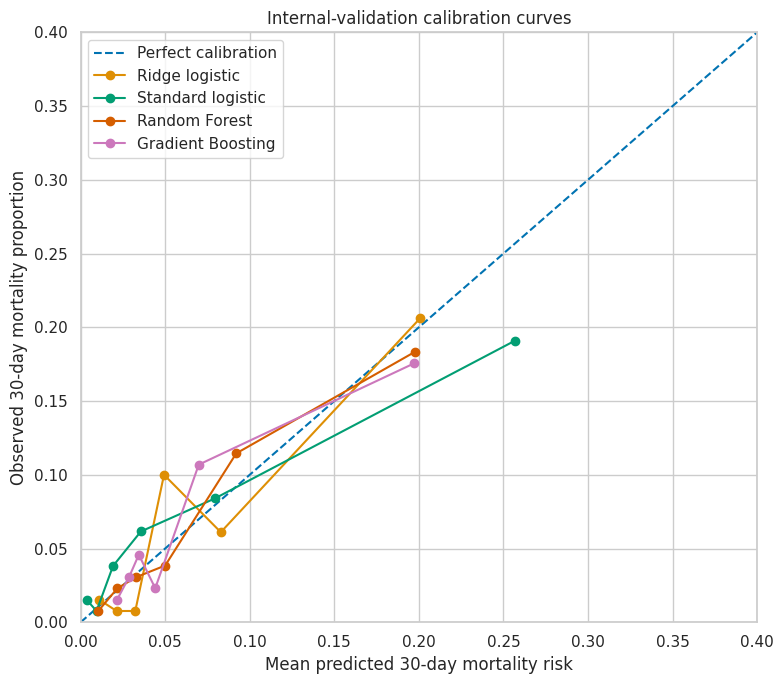


CALIBRATION RESULTS SAVED
/kaggle/working/ISDS/outputs/figures/candidate_model_calibration.png


In [27]:
# ============================================================
# 11.1 Calibration analysis
# Verified candidate models only
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

# ------------------------------------------------------------
# Verified patient-level OOF predictions
# ------------------------------------------------------------

calibration_sources = {
    "Ridge logistic":
        ridge_none_oof,

    "Standard logistic":
        standard_logistic_results["patient_oof"],

    "Random Forest":
        random_forest_results["patient_oof"],

    "Gradient Boosting":
        gradient_boosting_results["patient_oof"],
}

# ------------------------------------------------------------
# Calibration intercept and slope
#
# Ideal:
#   intercept = 0
#   slope     = 1
# ------------------------------------------------------------

calibration_rows = []

for model_name, prediction_data in calibration_sources.items():

    y_cal = (
        prediction_data["y_true"]
        .to_numpy()
    )

    p_cal = (
        prediction_data["predicted_probability"]
        .to_numpy()
    )

    # Avoid probabilities exactly equal to 0 or 1
    p_safe = np.clip(
        p_cal,
        1e-6,
        1 - 1e-6,
    )

    # Convert predicted probabilities to log-odds
    predicted_logit = np.log(
        p_safe / (1 - p_safe)
    ).reshape(-1, 1)

    # Calibration model:
    # observed outcome ~ predicted log-odds
    calibration_model = LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=20000,
    )

    calibration_model.fit(
        predicted_logit,
        y_cal,
    )

    calibration_intercept = float(
        calibration_model.intercept_[0]
    )

    calibration_slope = float(
        calibration_model.coef_[0, 0]
    )

    mean_predicted_risk = float(
        p_cal.mean()
    )

    observed_event_rate = float(
        y_cal.mean()
    )

    calibration_rows.append(
        {
            "model":
                model_name,

            "calibration_intercept":
                calibration_intercept,

            "calibration_slope":
                calibration_slope,

            "mean_predicted_risk":
                mean_predicted_risk,

            "observed_event_rate":
                observed_event_rate,

            "Brier_score":
                brier_score_loss(
                    y_cal,
                    p_cal,
                ),
        }
    )

calibration_summary = pd.DataFrame(
    calibration_rows
)

print("CALIBRATION SUMMARY")

display(
    calibration_summary.round(4)
)

# ------------------------------------------------------------
# Calibration curves
#
# Quantile bins are used because mortality is rare.
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 7)
)

plt.plot(
    [0, 0.40],
    [0, 0.40],
    "--",
    label="Perfect calibration",
)

for model_name, prediction_data in calibration_sources.items():

    y_cal = (
        prediction_data["y_true"]
        .to_numpy()
    )

    p_cal = (
        prediction_data["predicted_probability"]
        .to_numpy()
    )

    fraction_positive, mean_predicted = (
        calibration_curve(
            y_cal,
            p_cal,
            n_bins=6,
            strategy="quantile",
        )
    )

    plt.plot(
        mean_predicted,
        fraction_positive,
        marker="o",
        label=model_name,
    )

plt.xlabel(
    "Mean predicted 30-day mortality risk"
)

plt.ylabel(
    "Observed 30-day mortality proportion"
)

plt.title(
    "Internal-validation calibration curves"
)

plt.xlim(
    0,
    0.40,
)

plt.ylim(
    0,
    0.40,
)

plt.legend()

plt.tight_layout()

calibration_plot_path = (
    FIGURE_DIR
    / "candidate_model_calibration.png"
)

plt.savefig(
    calibration_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

calibration_summary.to_csv(
    TABLE_DIR
    / "candidate_model_calibration_summary.csv",
    index=False,
)

print(
    "\nCALIBRATION RESULTS SAVED"
)

print(
    calibration_plot_path
)

## 11. Uncertainty estimation


In [28]:
# ============================================================
# 12.1 Bootstrap uncertainty for final Ridge model
# Based on patient-level genuine OOF predictions
# ============================================================

from sklearn.utils import resample

BOOTSTRAP_REPS = 2000

rng = np.random.default_rng(
    RANDOM_SEED
)

ridge_eval = (
    ridge_none_oof[
        [
            "y_true",
            "predicted_probability",
        ]
    ]
    .reset_index(drop=True)
)

y_final = (
    ridge_eval["y_true"]
    .to_numpy()
)

p_final = (
    ridge_eval[
        "predicted_probability"
    ]
    .to_numpy()
)

n_patients = len(
    ridge_eval
)

bootstrap_rows = []

for bootstrap_id in range(
    BOOTSTRAP_REPS
):

    sample_indices = rng.integers(
        low=0,
        high=n_patients,
        size=n_patients,
    )

    y_boot = y_final[
        sample_indices
    ]

    p_boot = p_final[
        sample_indices
    ]

    # A bootstrap sample must contain
    # both outcome classes for ROC-AUC.
    if np.unique(
        y_boot
    ).size < 2:
        continue

    bootstrap_rows.append(
        {
            "ROC_AUC":
                roc_auc_score(
                    y_boot,
                    p_boot,
                ),

            "PR_AUC":
                average_precision_score(
                    y_boot,
                    p_boot,
                ),

            "Brier_score":
                brier_score_loss(
                    y_boot,
                    p_boot,
                ),

            "Log_loss":
                log_loss(
                    y_boot,
                    p_boot,
                ),
        }
    )

ridge_bootstrap = pd.DataFrame(
    bootstrap_rows
)

# ------------------------------------------------------------
# Point estimates + percentile 95% CI
# ------------------------------------------------------------

point_estimates = {
    "ROC_AUC":
        roc_auc_score(
            y_final,
            p_final,
        ),

    "PR_AUC":
        average_precision_score(
            y_final,
            p_final,
        ),

    "Brier_score":
        brier_score_loss(
            y_final,
            p_final,
        ),

    "Log_loss":
        log_loss(
            y_final,
            p_final,
        ),
}

ci_rows = []

for metric_name, point_value in (
    point_estimates.items()
):

    lower = ridge_bootstrap[
        metric_name
    ].quantile(0.025)

    upper = ridge_bootstrap[
        metric_name
    ].quantile(0.975)

    ci_rows.append(
        {
            "metric":
                metric_name,

            "estimate":
                point_value,

            "CI_2.5%":
                lower,

            "CI_97.5%":
                upper,
        }
    )

ridge_metric_ci = pd.DataFrame(
    ci_rows
)

print(
    "FINAL RIDGE MODEL — "
    "INTERNAL VALIDATION WITH 95% BOOTSTRAP CI"
)

display(
    ridge_metric_ci.round(4)
)

print(
    "\nSuccessful bootstrap samples:",
    len(ridge_bootstrap),
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

ridge_metric_ci.to_csv(
    TABLE_DIR
    / "final_ridge_metric_bootstrap_CI.csv",
    index=False,
)

ridge_bootstrap.to_csv(
    TABLE_DIR
    / "final_ridge_bootstrap_distribution.csv",
    index=False,
)

print(
    "\nRIDGE UNCERTAINTY RESULTS SAVED"
)

FINAL RIDGE MODEL — INTERNAL VALIDATION WITH 95% BOOTSTRAP CI


,metric,estimate,CI_2.5%,CI_97.5%
0,ROC_AUC,0.7881,0.7236,0.8478
1,PR_AUC,0.2783,0.1741,0.4054
2,Brier_score,0.0556,0.0423,0.0690
3,Log_loss,0.2070,0.1658,0.2487



Successful bootstrap samples: 2000

RIDGE UNCERTAINTY RESULTS SAVED


## 12. Final ridge model

### 12.1 Fit the selected model to all available data


In [31]:
# ============================================================
# 12.2 Fit final Ridge prediction model on all available data
# ============================================================

FINAL_RIDGE_C = 0.1

final_ridge_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor),
        ),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                C=FINAL_RIDGE_C,
                class_weight=None,
                max_iter=20000,
                tol=1e-4,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

final_ridge_pipeline.fit(
    X,
    y,
)

print(
    "FINAL RIDGE MODEL FIT COMPLETE"
)

print(
    f"Patients used: {len(X)}"
)

print(
    f"Deaths used: {int(y.sum())}"
)

print(
    f"Final C: {FINAL_RIDGE_C}"
)

print(
    "Class rebalancing: None"
)

FINAL RIDGE MODEL FIT COMPLETE
Patients used: 785
Deaths used: 52
Final C: 0.1
Class rebalancing: None


### 12.2 Coefficients and odds ratios


In [32]:
# ============================================================
# 12.3 Final Ridge coefficients and odds ratios
# ============================================================

final_preprocessor = (
    final_ridge_pipeline
    .named_steps[
        "preprocessor"
    ]
)

final_model = (
    final_ridge_pipeline
    .named_steps[
        "model"
    ]
)

feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

coefficients = (
    final_model
    .coef_[0]
)

coefficient_table = pd.DataFrame(
    {
        "feature":
            feature_names,

        "coefficient":
            coefficients,

        "odds_ratio":
            np.exp(
                coefficients
            ),

        "absolute_coefficient":
            np.abs(
                coefficients
            ),
    }
)

coefficient_table = (
    coefficient_table
    .sort_values(
        "absolute_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "FINAL RIDGE MODEL "
    "COEFFICIENTS AND ODDS RATIOS"
)

display(
    coefficient_table.round(4)
)

coefficient_table.to_csv(
    TABLE_DIR
    / "final_ridge_coefficients_odds_ratios.csv",
    index=False,
)

print(
    "\nFINAL RIDGE COEFFICIENT TABLE SAVED"
)

FINAL RIDGE MODEL COEFFICIENTS AND ODDS RATIOS


,feature,coefficient,odds_ratio,absolute_coefficient
0,Age,0.6554,1.9258,0.6554
1,Heart_rate,0.4691,1.5985,0.4691
2,Time_To_Relief,0.3208,1.3783,0.3208
3,Previous_myocardial_infarction,0.3139,1.3687,0.3139
4,Killip_class,0.3072,1.3596,0.3072
5,Anterior_infarct_location,0.2750,1.3165,0.2750
6,Gender,-0.2190,0.8033,0.2190
7,Weight,-0.2167,0.8052,0.2167
8,Diabetes,0.2082,1.2315,0.2082
9,Hypotension,0.1742,1.1903,0.1742



FINAL RIDGE COEFFICIENT TABLE SAVED


## 13. Sensitivity analyses


### 13.1 Killip class: ordinal versus categorical representation


In [34]:
# ============================================================
# 13.1 Sensitivity analysis
# Killip class: ordinal vs categorical representation
# CORRECTED VERSION WITH FIXED CATEGORY LEVELS
# ============================================================

# ------------------------------------------------------------
# Alternative feature grouping:
# Killip_class is treated as categorical
# instead of ordinal.
# ------------------------------------------------------------

continuous_features_killip_cat = [
    "Age",
    "Height",
    "Weight",
    "ST_elevation_leads",
]

binary_features_killip_cat = [
    "Gender",
    "Diabetes",
    "Hypotension",
    "Heart_rate",
    "Anterior_infarct_location",
    "Previous_myocardial_infarction",
    "Hypertension",
    "Hypercholesterolaemia",
    "Previous_angina_pectoris",
    "Family_history_of_MI",
    "Time_To_Relief",
]

categorical_features_killip_cat = [
    "Smoking",
    "Killip_class",
]

# ------------------------------------------------------------
# Leakage-safe preprocessing
# ------------------------------------------------------------

continuous_pipeline_killip_cat = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

binary_pipeline_killip_cat = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
    ]
)

# IMPORTANT:
# Categories are fixed from the assignment data dictionary,
# not learned from the validation folds.
#
# Smoking:
#   1 = never
#   2 = ex-smoker
#   3 = current smoker
#
# Killip:
#   classes 1, 2, 3, 4
#
# Therefore a rare Killip level remains structurally available
# even if it is absent from an individual training fold.
categorical_pipeline_killip_cat = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                categories=[
                    [1, 2, 3],
                    [1, 2, 3, 4],
                ],
                drop="first",
                handle_unknown="error",
                sparse_output=False,
            ),
        ),
    ]
)

killip_categorical_preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            continuous_pipeline_killip_cat,
            continuous_features_killip_cat,
        ),
        (
            "binary",
            binary_pipeline_killip_cat,
            binary_features_killip_cat,
        ),
        (
            "categorical",
            categorical_pipeline_killip_cat,
            categorical_features_killip_cat,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# ------------------------------------------------------------
# Same final model family as primary analysis
# ------------------------------------------------------------

killip_categorical_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            killip_categorical_preprocessor,
        ),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                class_weight=None,
                max_iter=20000,
                tol=1e-4,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

# Same hyperparameter grid as main Ridge analysis
killip_categorical_grid = {
    "model__C": [
        0.01,
        0.1,
        1.0,
    ]
}

# ------------------------------------------------------------
# Same repeated nested internal validation
# ------------------------------------------------------------

killip_categorical_results = evaluate_nested_model(
    model_name=(
        "RIDGE — KILLIP CATEGORICAL"
    ),
    pipeline=(
        killip_categorical_pipeline
    ),
    parameter_grid=(
        killip_categorical_grid
    ),
    file_prefix=(
        "ridge_killip_categorical"
    ),
)

# ------------------------------------------------------------
# Direct comparison:
# primary ordinal Killip vs categorical Killip
# ------------------------------------------------------------

killip_primary_vs_categorical = (
    ridge_none_metrics
    .rename(
        columns={
            "value":
                "killip_ordinal"
        }
    )
    .merge(
        killip_categorical_results[
            "metrics"
        ].rename(
            columns={
                "value":
                    "killip_categorical"
            }
        ),
        on="metric",
    )
)

killip_primary_vs_categorical[
    "categorical_minus_ordinal"
] = (
    killip_primary_vs_categorical[
        "killip_categorical"
    ]
    - killip_primary_vs_categorical[
        "killip_ordinal"
    ]
)

print(
    "\nSENSITIVITY ANALYSIS: "
    "KILLIP ORDINAL vs CATEGORICAL"
)

display(
    killip_primary_vs_categorical.round(4)
)

killip_primary_vs_categorical.to_csv(
    TABLE_DIR
    / "sensitivity_killip_ordinal_vs_categorical.csv",
    index=False,
)

print(
    "\nKILLIP SENSITIVITY RESULTS SAVED"
)

RUNNING: RIDGE — KILLIP CATEGORICAL
Outer validation: 5-fold x 5 repeats
Inner validation: 4-fold
Tuning criterion: log loss
Class rebalancing: None

Outer fold 01/25 complete | repeat=1, fold=1
Outer fold 02/25 complete | repeat=1, fold=2
Outer fold 03/25 complete | repeat=1, fold=3
Outer fold 04/25 complete | repeat=1, fold=4
Outer fold 05/25 complete | repeat=1, fold=5
Outer fold 06/25 complete | repeat=2, fold=1
Outer fold 07/25 complete | repeat=2, fold=2
Outer fold 08/25 complete | repeat=2, fold=3
Outer fold 09/25 complete | repeat=2, fold=4
Outer fold 10/25 complete | repeat=2, fold=5
Outer fold 11/25 complete | repeat=3, fold=1
Outer fold 12/25 complete | repeat=3, fold=2
Outer fold 13/25 complete | repeat=3, fold=3
Outer fold 14/25 complete | repeat=3, fold=4
Outer fold 15/25 complete | repeat=3, fold=5
Outer fold 16/25 complete | repeat=4, fold=1
Outer fold 17/25 complete | repeat=4, fold=2
Outer fold 18/25 complete | repeat=4, fold=3
Outer fold 19/25 complete | repeat=4, fo

,metric,value
0,ROC-AUC,0.7786
1,PR-AUC (average precision),0.2233
2,Brier score,0.0567
3,Log loss,0.2103



RIDGE — KILLIP CATEGORICAL HYPERPARAMETER FREQUENCY


,best_parameters,outer_folds_selected
0,{'model__C': 0.1},19
1,{'model__C': 1.0},6



RIDGE — KILLIP CATEGORICAL RESULT FILES SAVED

SENSITIVITY ANALYSIS: KILLIP ORDINAL vs CATEGORICAL


,metric,killip_ordinal,killip_categorical,categorical_minus_ordinal
0,ROC-AUC,0.7881,0.7786,-0.0095
1,PR-AUC (average precision),0.2783,0.2233,-0.0550
2,Brier score,0.0556,0.0567,0.0011
3,Log loss,0.2070,0.2103,0.0033



KILLIP SENSITIVITY RESULTS SAVED


### 13.2 Missing-indicator sensitivity


In [35]:
# ============================================================
# 13.2 Sensitivity analysis
# Primary Ridge model + explicit missingness indicators
# ============================================================

from sklearn.impute import MissingIndicator

# ------------------------------------------------------------
# Preprocessing:
# Primary preprocessing remains unchanged.
#
# Additional missingness flags are created for ALL candidate
# predictors. This avoids selecting indicator variables using
# information from held-out validation observations.
# ------------------------------------------------------------

preprocessor_with_missing_indicators = ColumnTransformer(
    transformers=[
        (
            "continuous_ordinal",
            clone(continuous_ordinal_pipeline),
            continuous_ordinal_features,
        ),
        (
            "binary",
            clone(binary_pipeline),
            binary_features,
        ),
        (
            "categorical",
            clone(categorical_pipeline),
            categorical_features,
        ),
        (
            "missing_indicators",
            MissingIndicator(
                features="all",
                error_on_new=False,
            ),
            all_model_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# ------------------------------------------------------------
# Same Ridge model family as the selected primary model
# ------------------------------------------------------------

ridge_missing_indicator_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_with_missing_indicators,
        ),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                class_weight=None,
                max_iter=20000,
                tol=1e-4,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

# Same tuning grid as the primary Ridge model
ridge_missing_indicator_grid = {
    "model__C": [
        0.01,
        0.1,
        1.0,
    ]
}

# ------------------------------------------------------------
# Same repeated nested internal-validation framework
# ------------------------------------------------------------

ridge_missing_indicator_results = evaluate_nested_model(
    model_name=(
        "RIDGE — MISSING INDICATORS"
    ),
    pipeline=(
        ridge_missing_indicator_pipeline
    ),
    parameter_grid=(
        ridge_missing_indicator_grid
    ),
    file_prefix=(
        "ridge_missing_indicators"
    ),
)

# ------------------------------------------------------------
# Direct sensitivity comparison:
# Primary imputation-only Ridge
# versus Ridge + missing indicators
# ------------------------------------------------------------

missing_indicator_comparison = (
    ridge_none_metrics
    .rename(
        columns={
            "value":
                "primary_imputation_only"
        }
    )
    .merge(
        ridge_missing_indicator_results[
            "metrics"
        ].rename(
            columns={
                "value":
                    "imputation_plus_indicators"
            }
        ),
        on="metric",
    )
)

missing_indicator_comparison[
    "indicator_minus_primary"
] = (
    missing_indicator_comparison[
        "imputation_plus_indicators"
    ]
    - missing_indicator_comparison[
        "primary_imputation_only"
    ]
)

print(
    "\nSENSITIVITY ANALYSIS: "
    "IMPUTATION ONLY vs MISSING INDICATORS"
)

display(
    missing_indicator_comparison.round(4)
)

# ------------------------------------------------------------
# Record which predictors actually contain missing values
# for transparent reporting.
# ------------------------------------------------------------

observed_missingness = (
    X.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

observed_missingness[
    "missing_percent"
] = (
    100
    * observed_missingness[
        "missing_count"
    ]
    / len(X)
)

observed_missingness = (
    observed_missingness
    .query(
        "missing_count > 0"
    )
    .sort_values(
        "missing_count",
        ascending=False,
    )
)

print(
    "\nPREDICTORS WITH OBSERVED MISSINGNESS"
)

display(
    observed_missingness.round(3)
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

missing_indicator_comparison.to_csv(
    TABLE_DIR
    / "sensitivity_missing_indicators.csv",
    index=False,
)

observed_missingness.to_csv(
    TABLE_DIR
    / "missingness_variables_for_report.csv"
)

print(
    "\nMISSING-INDICATOR "
    "SENSITIVITY RESULTS SAVED"
)

RUNNING: RIDGE — MISSING INDICATORS
Outer validation: 5-fold x 5 repeats
Inner validation: 4-fold
Tuning criterion: log loss
Class rebalancing: None

Outer fold 01/25 complete | repeat=1, fold=1
Outer fold 02/25 complete | repeat=1, fold=2
Outer fold 03/25 complete | repeat=1, fold=3
Outer fold 04/25 complete | repeat=1, fold=4
Outer fold 05/25 complete | repeat=1, fold=5
Outer fold 06/25 complete | repeat=2, fold=1
Outer fold 07/25 complete | repeat=2, fold=2
Outer fold 08/25 complete | repeat=2, fold=3
Outer fold 09/25 complete | repeat=2, fold=4
Outer fold 10/25 complete | repeat=2, fold=5
Outer fold 11/25 complete | repeat=3, fold=1
Outer fold 12/25 complete | repeat=3, fold=2
Outer fold 13/25 complete | repeat=3, fold=3
Outer fold 14/25 complete | repeat=3, fold=4
Outer fold 15/25 complete | repeat=3, fold=5
Outer fold 16/25 complete | repeat=4, fold=1
Outer fold 17/25 complete | repeat=4, fold=2
Outer fold 18/25 complete | repeat=4, fold=3
Outer fold 19/25 complete | repeat=4, fo

,metric,value
0,ROC-AUC,0.7889
1,PR-AUC (average precision),0.2787
2,Brier score,0.0556
3,Log loss,0.2069



RIDGE — MISSING INDICATORS HYPERPARAMETER FREQUENCY


,best_parameters,outer_folds_selected
0,{'model__C': 0.1},22
1,{'model__C': 1.0},3



RIDGE — MISSING INDICATORS RESULT FILES SAVED

SENSITIVITY ANALYSIS: IMPUTATION ONLY vs MISSING INDICATORS


,metric,primary_imputation_only,imputation_plus_indicators,indicator_minus_primary
0,ROC-AUC,0.7881,0.7889,0.0008
1,PR-AUC (average precision),0.2783,0.2787,0.0003
2,Brier score,0.0556,0.0556,-0.0000
3,Log loss,0.2070,0.2069,-0.0001



PREDICTORS WITH OBSERVED MISSINGNESS


,missing_count,missing_percent
Killip_class,15,1.911
Hypotension,4,0.510
Gender,2,0.255
Age,1,0.127
Anterior_infarct_location,1,0.127
Height,1,0.127



MISSING-INDICATOR SENSITIVITY RESULTS SAVED


### 13.3 Intercept-only reference model


In [36]:
# ============================================================
# 13.3 Intercept-only / prevalence reference model
# Same repeated outer validation
# ============================================================

from sklearn.dummy import DummyClassifier

# ------------------------------------------------------------
# Intercept-only prediction:
# the model predicts the mortality prevalence learned
# from each outer training set.
#
# No predictors, no tuning, no rebalancing.
# ------------------------------------------------------------

null_prediction_rows = []

print("RUNNING INTERCEPT-ONLY REFERENCE MODEL")
print(
    f"Outer validation: {OUTER_SPLITS}-fold x "
    f"{OUTER_REPEATS} repeats"
)
print("Strategy: training-fold class prevalence")
print()

for split_id, (train_idx, test_idx) in enumerate(
    outer_cv.split(X, y),
    start=1,
):

    repeat_number = (
        (split_id - 1) // OUTER_SPLITS
    ) + 1

    fold_number = (
        (split_id - 1) % OUTER_SPLITS
    ) + 1

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Dummy X is used because sklearn classifiers
    # require a design matrix, although no predictor
    # information is used.
    X_train_dummy = np.zeros(
        (len(train_idx), 1)
    )

    X_test_dummy = np.zeros(
        (len(test_idx), 1)
    )

    null_model = DummyClassifier(
        strategy="prior"
    )

    null_model.fit(
        X_train_dummy,
        y_train,
    )

    predicted_probability = (
        null_model
        .predict_proba(
            X_test_dummy
        )[:, 1]
    )

    for local_position, original_position in enumerate(
        test_idx
    ):

        null_prediction_rows.append(
            {
                "patient_index":
                    X.index[original_position],
                "repeat":
                    repeat_number,
                "fold":
                    fold_number,
                "y_true":
                    int(
                        y_test.iloc[
                            local_position
                        ]
                    ),
                "predicted_probability":
                    float(
                        predicted_probability[
                            local_position
                        ]
                    ),
            }
        )

    print(
        f"Outer fold {split_id:02d}/"
        f"{total_outer_folds} complete"
    )

print(
    "\nINTERCEPT-ONLY OUTER VALIDATION COMPLETE"
)

# ------------------------------------------------------------
# Aggregate OOF predictions across repeats
# ------------------------------------------------------------

null_repeated_oof = pd.DataFrame(
    null_prediction_rows
)

null_patient_oof = (
    null_repeated_oof
    .groupby(
        "patient_index",
        as_index=False,
    )
    .agg(
        y_true=(
            "y_true",
            "first",
        ),
        predicted_probability=(
            "predicted_probability",
            "mean",
        ),
        n_oof_predictions=(
            "predicted_probability",
            "size",
        ),
    )
)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

assert len(
    null_patient_oof
) == len(X)

assert (
    null_patient_oof[
        "n_oof_predictions"
    ]
    .eq(
        OUTER_REPEATS
    )
    .all()
)

assert int(
    null_patient_oof[
        "y_true"
    ].sum()
) == 52

print(
    "\nINTERCEPT-ONLY OOF CHECK PASSED"
)

# ------------------------------------------------------------
# Performance
# ------------------------------------------------------------

y_null = (
    null_patient_oof[
        "y_true"
    ].to_numpy()
)

p_null = (
    null_patient_oof[
        "predicted_probability"
    ].to_numpy()
)

null_metrics = pd.DataFrame(
    {
        "metric": [
            "ROC-AUC",
            "PR-AUC (average precision)",
            "Brier score",
            "Log loss",
        ],
        "value": [
            roc_auc_score(
                y_null,
                p_null,
            ),
            average_precision_score(
                y_null,
                p_null,
            ),
            brier_score_loss(
                y_null,
                p_null,
            ),
            log_loss(
                y_null,
                p_null,
            ),
        ],
    }
)

print(
    "\nINTERCEPT-ONLY INTERNALLY "
    "VALIDATED PERFORMANCE"
)

display(
    null_metrics.round(4)
)

# ------------------------------------------------------------
# Compare final Ridge against null reference
# ------------------------------------------------------------

ridge_vs_null = (
    null_metrics
    .rename(
        columns={
            "value":
                "intercept_only"
        }
    )
    .merge(
        ridge_none_metrics.rename(
            columns={
                "value":
                    "ridge_logistic"
            }
        ),
        on="metric",
    )
)

ridge_vs_null[
    "ridge_minus_null"
] = (
    ridge_vs_null[
        "ridge_logistic"
    ]
    - ridge_vs_null[
        "intercept_only"
    ]
)

print(
    "\nFINAL RIDGE vs INTERCEPT-ONLY REFERENCE"
)

display(
    ridge_vs_null.round(4)
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

null_repeated_oof.to_csv(
    TABLE_DIR
    / "intercept_only_repeated_oof.csv",
    index=False,
)

null_patient_oof.to_csv(
    TABLE_DIR
    / "intercept_only_patient_oof.csv",
    index=False,
)

null_metrics.to_csv(
    TABLE_DIR
    / "intercept_only_metrics.csv",
    index=False,
)

ridge_vs_null.to_csv(
    TABLE_DIR
    / "ridge_vs_intercept_only.csv",
    index=False,
)

print(
    "\nINTERCEPT-ONLY REFERENCE RESULTS SAVED"
)

RUNNING INTERCEPT-ONLY REFERENCE MODEL
Outer validation: 5-fold x 5 repeats
Strategy: training-fold class prevalence

Outer fold 01/25 complete
Outer fold 02/25 complete
Outer fold 03/25 complete
Outer fold 04/25 complete
Outer fold 05/25 complete
Outer fold 06/25 complete
Outer fold 07/25 complete
Outer fold 08/25 complete
Outer fold 09/25 complete
Outer fold 10/25 complete
Outer fold 11/25 complete
Outer fold 12/25 complete
Outer fold 13/25 complete
Outer fold 14/25 complete
Outer fold 15/25 complete
Outer fold 16/25 complete
Outer fold 17/25 complete
Outer fold 18/25 complete
Outer fold 19/25 complete
Outer fold 20/25 complete
Outer fold 21/25 complete
Outer fold 22/25 complete
Outer fold 23/25 complete
Outer fold 24/25 complete
Outer fold 25/25 complete

INTERCEPT-ONLY OUTER VALIDATION COMPLETE

INTERCEPT-ONLY OOF CHECK PASSED

INTERCEPT-ONLY INTERNALLY VALIDATED PERFORMANCE


,metric,value
0,ROC-AUC,0.4638
1,PR-AUC (average precision),0.0631
2,Brier score,0.0619
3,Log loss,0.2438



FINAL RIDGE vs INTERCEPT-ONLY REFERENCE


,metric,intercept_only,ridge_logistic,ridge_minus_null
0,ROC-AUC,0.4638,0.7881,0.3243
1,PR-AUC (average precision),0.0631,0.2783,0.2152
2,Brier score,0.0619,0.0556,-0.0062
3,Log loss,0.2438,0.2070,-0.0368



INTERCEPT-ONLY REFERENCE RESULTS SAVED


## 14. Threshold-based classification performance


In [37]:
# ============================================================
# 14.1 Threshold-based classification summaries
# Final Ridge model — genuine OOF predictions
# ============================================================

from sklearn.metrics import confusion_matrix

# ------------------------------------------------------------
# Use internally validated patient-level OOF probabilities
# from the selected Ridge model.
#
# Thresholds are pre-specified transparently rather than
# optimised on the same data.
# ------------------------------------------------------------

thresholds = [
    0.05,
    0.10,
    0.15,
    0.20,
]

y_threshold = (
    ridge_none_oof[
        "y_true"
    ]
    .to_numpy()
)

p_threshold = (
    ridge_none_oof[
        "predicted_probability"
    ]
    .to_numpy()
)

threshold_rows = []

for threshold in thresholds:

    predicted_class = (
        p_threshold >= threshold
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            y_threshold,
            predicted_class,
            labels=[0, 1],
        )
        .ravel()
    )

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    ppv = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )

    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )

    fraction_flagged = (
        (tp + fp)
        / len(y_threshold)
    )

    threshold_rows.append(
        {
            "risk_threshold":
                threshold,

            "TP":
                int(tp),

            "FP":
                int(fp),

            "TN":
                int(tn),

            "FN":
                int(fn),

            "sensitivity":
                sensitivity,

            "specificity":
                specificity,

            "PPV":
                ppv,

            "NPV":
                npv,

            "fraction_classified_high_risk":
                fraction_flagged,
        }
    )

threshold_summary = pd.DataFrame(
    threshold_rows
)

# ------------------------------------------------------------
# Display percentages for readability
# ------------------------------------------------------------

threshold_display = (
    threshold_summary.copy()
)

for column in [
    "risk_threshold",
    "sensitivity",
    "specificity",
    "PPV",
    "NPV",
    "fraction_classified_high_risk",
]:
    threshold_display[column] = (
        100
        * threshold_display[column]
    )

threshold_display = (
    threshold_display.rename(
        columns={
            "risk_threshold":
                "Risk threshold (%)",

            "sensitivity":
                "Sensitivity (%)",

            "specificity":
                "Specificity (%)",

            "PPV":
                "PPV (%)",

            "NPV":
                "NPV (%)",

            "fraction_classified_high_risk":
                "Patients flagged high risk (%)",
        }
    )
)

print(
    "FINAL RIDGE MODEL — "
    "THRESHOLD-BASED CLASSIFICATION PERFORMANCE"
)

display(
    threshold_display.round(1)
)

# ------------------------------------------------------------
# Save original proportion-scale results
# ------------------------------------------------------------

threshold_summary.to_csv(
    TABLE_DIR
    / "final_ridge_threshold_classification_metrics.csv",
    index=False,
)

print(
    "\nTHRESHOLD CLASSIFICATION RESULTS SAVED"
)

FINAL RIDGE MODEL — THRESHOLD-BASED CLASSIFICATION PERFORMANCE


,Risk threshold (%),TP,FP,TN,FN,Sensitivity (%),Specificity (%),PPV (%),NPV (%),Patients flagged high risk (%)
0,5.0,41,279,454,11,78.8,61.9,12.8,97.6,40.8
1,10.0,28,124,609,24,53.8,83.1,18.4,96.2,19.4
2,15.0,20,55,678,32,38.5,92.5,26.7,95.5,9.6
3,20.0,12,32,701,40,23.1,95.6,27.3,94.6,5.6



THRESHOLD CLASSIFICATION RESULTS SAVED


## 15. Decision-curve analysis


DECISION CURVE ANALYSIS
Patients: 785
Observed mortality prevalence: 0.0662

DECISION CURVE SUMMARY AT PRE-SPECIFIED THRESHOLDS


,Risk threshold (%),Ridge net benefit,Treat-all net benefit,Treat-none net benefit,Ridge minus treat-all,Ridge minus treat-none
0,5.0,0.0335,0.0171,0.0,0.0164,0.0335
1,10.0,0.0181,-0.0375,0.0,0.0556,0.0181
2,15.0,0.0131,-0.0985,0.0,0.1117,0.0131
3,20.0,0.0051,-0.1672,0.0,0.1723,0.0051


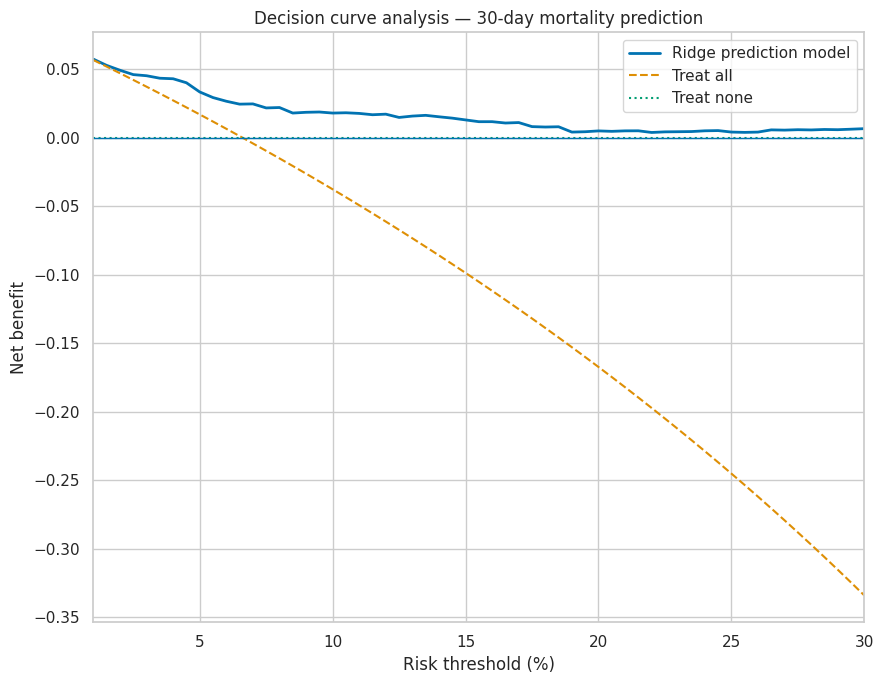


Within the evaluated grid, Ridge had greater net benefit than both reference strategies from approximately 1.0% to 30.0%.

DECISION CURVE RESULTS SAVED
/kaggle/working/ISDS/outputs/figures/final_ridge_decision_curve.png


In [38]:
# ============================================================
# 15.1 Decision Curve Analysis
# Selected Ridge model — genuine OOF predictions
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Use genuine internally validated OOF predictions
# ------------------------------------------------------------

y_dca = (
    ridge_none_oof["y_true"]
    .to_numpy()
)

p_dca = (
    ridge_none_oof["predicted_probability"]
    .to_numpy()
)

N = len(y_dca)

prevalence = y_dca.mean()

print("DECISION CURVE ANALYSIS")
print(f"Patients: {N}")
print(f"Observed mortality prevalence: {prevalence:.4f}")
print()

# ------------------------------------------------------------
# Decision-curve net benefit
#
# Net Benefit =
# TP/N - FP/N * pt/(1-pt)
#
# pt = threshold probability
# ------------------------------------------------------------

def model_net_benefit(
    y_true,
    predicted_probability,
    threshold,
):
    predicted_positive = (
        predicted_probability >= threshold
    )

    tp = np.sum(
        (predicted_positive == 1)
        & (y_true == 1)
    )

    fp = np.sum(
        (predicted_positive == 1)
        & (y_true == 0)
    )

    weight = (
        threshold
        / (1 - threshold)
    )

    net_benefit = (
        (tp / len(y_true))
        -
        (fp / len(y_true))
        * weight
    )

    return net_benefit


def treat_all_net_benefit(
    prevalence,
    threshold,
):
    return (
        prevalence
        -
        (1 - prevalence)
        * (
            threshold
            / (1 - threshold)
        )
    )


# ------------------------------------------------------------
# Plausible threshold range
#
# 1% to 30% is displayed.
# Assignment provides no externally established
# clinical intervention threshold.
# ------------------------------------------------------------

dca_thresholds = np.arange(
    0.01,
    0.301,
    0.005,
)

dca_rows = []

for threshold in dca_thresholds:

    nb_model = model_net_benefit(
        y_dca,
        p_dca,
        threshold,
    )

    nb_all = treat_all_net_benefit(
        prevalence,
        threshold,
    )

    nb_none = 0.0

    dca_rows.append(
        {
            "threshold":
                threshold,

            "ridge_net_benefit":
                nb_model,

            "treat_all_net_benefit":
                nb_all,

            "treat_none_net_benefit":
                nb_none,

            "ridge_minus_treat_all":
                nb_model - nb_all,

            "ridge_minus_treat_none":
                nb_model - nb_none,
        }
    )

dca_results = pd.DataFrame(
    dca_rows
)

# ------------------------------------------------------------
# Display key thresholds used in Step 14
# ------------------------------------------------------------

key_thresholds = [
    0.05,
    0.10,
    0.15,
    0.20,
]

key_dca_rows = []

for threshold in key_thresholds:

    nb_model = model_net_benefit(
        y_dca,
        p_dca,
        threshold,
    )

    nb_all = treat_all_net_benefit(
        prevalence,
        threshold,
    )

    key_dca_rows.append(
        {
            "Risk threshold (%)":
                threshold * 100,

            "Ridge net benefit":
                nb_model,

            "Treat-all net benefit":
                nb_all,

            "Treat-none net benefit":
                0.0,

            "Ridge minus treat-all":
                nb_model - nb_all,

            "Ridge minus treat-none":
                nb_model,
        }
    )

key_dca_summary = pd.DataFrame(
    key_dca_rows
)

print(
    "DECISION CURVE SUMMARY "
    "AT PRE-SPECIFIED THRESHOLDS"
)

display(
    key_dca_summary.round(4)
)

# ------------------------------------------------------------
# Decision curve
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 7)
)

plt.plot(
    100 * dca_results["threshold"],
    dca_results["ridge_net_benefit"],
    label="Ridge prediction model",
    linewidth=2,
)

plt.plot(
    100 * dca_results["threshold"],
    dca_results["treat_all_net_benefit"],
    label="Treat all",
    linestyle="--",
)

plt.plot(
    100 * dca_results["threshold"],
    dca_results["treat_none_net_benefit"],
    label="Treat none",
    linestyle=":",
)

plt.axhline(
    0,
    linewidth=1,
)

plt.xlabel(
    "Risk threshold (%)"
)

plt.ylabel(
    "Net benefit"
)

plt.title(
    "Decision curve analysis — "
    "30-day mortality prediction"
)

plt.xlim(
    1,
    30,
)

plt.legend()

plt.tight_layout()

dca_plot_path = (
    FIGURE_DIR
    / "final_ridge_decision_curve.png"
)

plt.savefig(
    dca_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------
# Determine threshold regions where Ridge has
# greater net benefit than both reference strategies.
# ------------------------------------------------------------

dca_results[
    "ridge_best_strategy"
] = (
    (
        dca_results["ridge_net_benefit"]
        >
        dca_results["treat_all_net_benefit"]
    )
    &
    (
        dca_results["ridge_net_benefit"]
        >
        dca_results["treat_none_net_benefit"]
    )
)

useful_thresholds = (
    dca_results.loc[
        dca_results[
            "ridge_best_strategy"
        ],
        "threshold",
    ]
)

if len(useful_thresholds) > 0:

    useful_min = (
        useful_thresholds.min()
    )

    useful_max = (
        useful_thresholds.max()
    )

    print(
        "\nWithin the evaluated grid, "
        "Ridge had greater net benefit "
        "than both reference strategies "
        f"from approximately "
        f"{100 * useful_min:.1f}% "
        f"to {100 * useful_max:.1f}%."
    )

else:

    print(
        "\nRidge was not superior to both "
        "reference strategies at any "
        "evaluated threshold."
    )

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

dca_results.to_csv(
    TABLE_DIR
    / "final_ridge_decision_curve_full.csv",
    index=False,
)

key_dca_summary.to_csv(
    TABLE_DIR
    / "final_ridge_decision_curve_key_thresholds.csv",
    index=False,
)

print(
    "\nDECISION CURVE RESULTS SAVED"
)

print(
    dca_plot_path
)

## 16. Outer-fold permutation importance


RUNNING OUTER-FOLD PERMUTATION IMPORTANCE
Outer folds: 5 x 5
Permutation repeats per predictor/fold: 20
Importance metric: increase in held-out log loss

Outer fold 01/25 complete | repeat=1, fold=1, C=1.0
Outer fold 02/25 complete | repeat=1, fold=2, C=0.1
Outer fold 03/25 complete | repeat=1, fold=3, C=0.1
Outer fold 04/25 complete | repeat=1, fold=4, C=0.1
Outer fold 05/25 complete | repeat=1, fold=5, C=0.1
Outer fold 06/25 complete | repeat=2, fold=1, C=0.1
Outer fold 07/25 complete | repeat=2, fold=2, C=1.0
Outer fold 08/25 complete | repeat=2, fold=3, C=0.1
Outer fold 09/25 complete | repeat=2, fold=4, C=0.1
Outer fold 10/25 complete | repeat=2, fold=5, C=0.1
Outer fold 11/25 complete | repeat=3, fold=1, C=0.1
Outer fold 12/25 complete | repeat=3, fold=2, C=0.1
Outer fold 13/25 complete | repeat=3, fold=3, C=0.1
Outer fold 14/25 complete | repeat=3, fold=4, C=0.1
Outer fold 15/25 complete | repeat=3, fold=5, C=0.1
Outer fold 16/25 complete | repeat=4, fold=1, C=0.1
Outer fold 17/

,feature,mean_log_loss_increase,SD_log_loss_increase,median_log_loss_increase,mean_ROC_AUC_drop,SD_ROC_AUC_drop
0,Age,0.02714,0.01500,0.02747,0.12370,0.07417
1,Killip_class,0.00881,0.00761,0.00959,0.02552,0.03403
2,Heart_rate,0.00524,0.00534,0.00548,0.01711,0.02147
3,Time_To_Relief,0.00268,0.00362,0.00261,0.01138,0.01604
4,Weight,0.00259,0.00594,0.00311,0.00734,0.02367
5,Previous_myocardial_infarction,0.00171,0.00311,0.00218,0.00773,0.01338
6,Anterior_infarct_location,0.00134,0.00370,0.00184,0.00710,0.01567
7,Gender,0.00100,0.00495,0.00082,0.00171,0.01304
8,Height,0.00041,0.00406,0.00087,0.00293,0.01394
9,Hypotension,0.00031,0.00129,0.00029,0.00098,0.00445


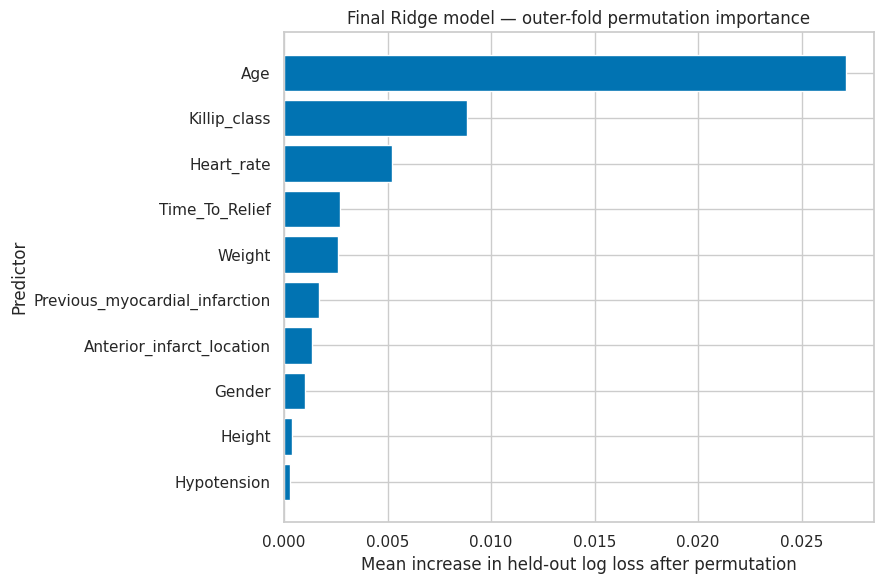


TOP 10 FINAL-MODEL COEFFICIENTS


,feature,coefficient,odds_ratio,absolute_coefficient
0,Age,0.6554,1.9258,0.6554
1,Heart_rate,0.4691,1.5985,0.4691
2,Time_To_Relief,0.3208,1.3783,0.3208
3,Previous_myocardial_infarction,0.3139,1.3687,0.3139
4,Killip_class,0.3072,1.3596,0.3072
5,Anterior_infarct_location,0.2750,1.3165,0.2750
6,Gender,-0.2190,0.8033,0.2190
7,Weight,-0.2167,0.8052,0.2167
8,Diabetes,0.2082,1.2315,0.2082
9,Hypotension,0.1742,1.1903,0.1742



PERMUTATION IMPORTANCE RESULTS SAVED
/kaggle/working/ISDS/outputs/figures/final_ridge_permutation_importance.png


In [39]:
# ============================================================
# 16.1 Outer-fold permutation importance
# Selected Ridge logistic model
# Importance = increase in held-out log loss after permutation
# ============================================================

from sklearn.base import clone

PERMUTATION_REPEATS = 20

permutation_rows = []

print("RUNNING OUTER-FOLD PERMUTATION IMPORTANCE")
print(f"Outer folds: {OUTER_SPLITS} x {OUTER_REPEATS}")
print(f"Permutation repeats per predictor/fold: {PERMUTATION_REPEATS}")
print("Importance metric: increase in held-out log loss")
print()

# ------------------------------------------------------------
# Recover the selected C for each Ridge outer fold
# ------------------------------------------------------------

ridge_tuning_lookup = {
    (
        int(row["repeat"]),
        int(row["fold"]),
    ): float(row["best_C"])
    for _, row in ridge_none_tuning_results.iterrows()
}

assert len(ridge_tuning_lookup) == 25

# ------------------------------------------------------------
# Re-run the SAME outer splits.
#
# For each fold:
# 1. fit Ridge using that fold's previously selected C
# 2. calculate baseline test-fold log loss
# 3. independently permute each raw predictor in X_test
# 4. measure deterioration in test-fold log loss
#
# Positive importance:
#   model becomes worse after permuting predictor
# ------------------------------------------------------------

for split_id, (train_idx, test_idx) in enumerate(
    outer_cv.split(X, y),
    start=1,
):

    repeat_number = (
        (split_id - 1) // OUTER_SPLITS
    ) + 1

    fold_number = (
        (split_id - 1) % OUTER_SPLITS
    ) + 1

    best_C = ridge_tuning_lookup[
        (
            repeat_number,
            fold_number,
        )
    ]

    X_train = X.iloc[
        train_idx
    ].copy()

    y_train = y.iloc[
        train_idx
    ].copy()

    X_test = X.iloc[
        test_idx
    ].copy()

    y_test = y.iloc[
        test_idx
    ].copy()

    # --------------------------------------------------------
    # Fit selected Ridge specification on outer training fold
    # --------------------------------------------------------

    fold_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "model",
                LogisticRegression(
                    penalty="l2",
                    solver="lbfgs",
                    C=best_C,
                    class_weight=None,
                    max_iter=20000,
                    tol=1e-4,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )

    fold_pipeline.fit(
        X_train,
        y_train,
    )

    baseline_probability = (
        fold_pipeline.predict_proba(
            X_test
        )[:, 1]
    )

    baseline_log_loss = log_loss(
        y_test,
        baseline_probability,
    )

    baseline_auc = roc_auc_score(
        y_test,
        baseline_probability,
    )

    # --------------------------------------------------------
    # Permute one RAW predictor at a time
    # --------------------------------------------------------

    for feature_id, feature_name in enumerate(
        all_model_features
    ):

        for permutation_id in range(
            PERMUTATION_REPEATS
        ):

            # deterministic but different seed for each
            # fold / feature / permutation
            permutation_seed = (
                RANDOM_SEED
                + split_id * 100000
                + feature_id * 1000
                + permutation_id
            )

            rng_perm = np.random.default_rng(
                permutation_seed
            )

            X_test_permuted = (
                X_test.copy()
            )

            original_values = (
                X_test_permuted[
                    feature_name
                ]
                .to_numpy(
                    copy=True
                )
            )

            permuted_values = (
                original_values[
                    rng_perm.permutation(
                        len(
                            original_values
                        )
                    )
                ]
            )

            X_test_permuted[
                feature_name
            ] = permuted_values

            permuted_probability = (
                fold_pipeline.predict_proba(
                    X_test_permuted
                )[:, 1]
            )

            permuted_log_loss = log_loss(
                y_test,
                permuted_probability,
            )

            permuted_auc = roc_auc_score(
                y_test,
                permuted_probability,
            )

            permutation_rows.append(
                {
                    "repeat":
                        repeat_number,

                    "fold":
                        fold_number,

                    "feature":
                        feature_name,

                    "permutation_repeat":
                        permutation_id + 1,

                    "best_C":
                        best_C,

                    "baseline_log_loss":
                        baseline_log_loss,

                    "permuted_log_loss":
                        permuted_log_loss,

                    # Main importance measure
                    "log_loss_increase":
                        (
                            permuted_log_loss
                            - baseline_log_loss
                        ),

                    "baseline_ROC_AUC":
                        baseline_auc,

                    "permuted_ROC_AUC":
                        permuted_auc,

                    # Secondary descriptive measure
                    "ROC_AUC_drop":
                        (
                            baseline_auc
                            - permuted_auc
                        ),
                }
            )

    print(
        f"Outer fold {split_id:02d}/"
        f"{total_outer_folds} complete | "
        f"repeat={repeat_number}, "
        f"fold={fold_number}, "
        f"C={best_C}"
    )

print(
    "\nOUTER-FOLD PERMUTATION IMPORTANCE COMPLETE"
)

# ------------------------------------------------------------
# Aggregate
# ------------------------------------------------------------

permutation_importance_raw = pd.DataFrame(
    permutation_rows
)

permutation_importance_summary = (
    permutation_importance_raw
    .groupby(
        "feature",
        as_index=False,
    )
    .agg(
        mean_log_loss_increase=(
            "log_loss_increase",
            "mean",
        ),
        SD_log_loss_increase=(
            "log_loss_increase",
            "std",
        ),
        median_log_loss_increase=(
            "log_loss_increase",
            "median",
        ),
        mean_ROC_AUC_drop=(
            "ROC_AUC_drop",
            "mean",
        ),
        SD_ROC_AUC_drop=(
            "ROC_AUC_drop",
            "std",
        ),
    )
    .sort_values(
        "mean_log_loss_increase",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "\nOUTER-FOLD PERMUTATION IMPORTANCE SUMMARY"
)

display(
    permutation_importance_summary.round(5)
)

# ------------------------------------------------------------
# Top-10 plot
# ------------------------------------------------------------

top_importance = (
    permutation_importance_summary
    .head(10)
    .sort_values(
        "mean_log_loss_increase",
        ascending=True,
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    top_importance[
        "feature"
    ],
    top_importance[
        "mean_log_loss_increase"
    ],
)

plt.xlabel(
    "Mean increase in held-out log loss after permutation"
)

plt.ylabel(
    "Predictor"
)

plt.title(
    "Final Ridge model — "
    "outer-fold permutation importance"
)

plt.tight_layout()

permutation_plot_path = (
    FIGURE_DIR
    / "final_ridge_permutation_importance.png"
)

plt.savefig(
    permutation_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------
# Compare top permutation importance with coefficient ranking
# ------------------------------------------------------------

top_coefficient_predictors = (
    coefficient_table[
        [
            "feature",
            "coefficient",
            "odds_ratio",
            "absolute_coefficient",
        ]
    ]
    .head(10)
)

print(
    "\nTOP 10 FINAL-MODEL COEFFICIENTS"
)

display(
    top_coefficient_predictors.round(4)
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

permutation_importance_raw.to_csv(
    TABLE_DIR
    / "final_ridge_permutation_importance_raw.csv",
    index=False,
)

permutation_importance_summary.to_csv(
    TABLE_DIR
    / "final_ridge_permutation_importance_summary.csv",
    index=False,
)

print(
    "\nPERMUTATION IMPORTANCE RESULTS SAVED"
)

print(
    permutation_plot_path
)

## 17. Final reproducibility and assignment audit


In [40]:
# ============================================================
# 17.1 Final reproducibility and assignment audit
# ============================================================

import joblib
import json
from pathlib import Path

# ------------------------------------------------------------
# 1. Save the selected full-data Ridge pipeline
# ------------------------------------------------------------

final_model_path = (
    MODEL_DIR
    / "final_ridge_prediction_pipeline.joblib"
)

joblib.dump(
    final_ridge_pipeline,
    final_model_path,
)

assert final_model_path.exists()

print("FINAL MODEL SAVED")
print(final_model_path)

# ------------------------------------------------------------
# 2. Save model metadata
# ------------------------------------------------------------

final_model_metadata = {
    "project":
        "ISDS Option A - 30-day mortality prediction",

    "outcome":
        OUTCOME,

    "n_patients":
        int(len(X)),

    "n_events":
        int(y.sum()),

    "event_rate":
        float(y.mean()),

    "candidate_predictors":
        list(X.columns),

    "selected_model":
        "Ridge-penalised logistic regression",

    "penalty":
        "L2",

    "solver":
        "lbfgs",

    "final_C":
        float(FINAL_RIDGE_C),

    "class_rebalancing":
        "None",

    "missing_data":
        (
            "Fold-specific median imputation for "
            "continuous/ordinal variables and "
            "most-frequent imputation for binary/"
            "categorical variables"
        ),

    "scaling":
        (
            "Continuous/ordinal predictors "
            "standardised within training folds"
        ),

    "internal_validation":
        (
            "5-fold stratified outer CV x 5 repeats; "
            "4-fold stratified inner CV for tuning"
        ),

    "tuning_metric":
        "log loss",

    "random_seed":
        int(RANDOM_SEED),

    "raw_sha256":
        RAW_SHA256
        if "RAW_SHA256" in globals()
        else None,

    "model_selection_reason":
        (
            "Best overall balance of discrimination, "
            "proper scoring-rule performance, calibration, "
            "and repeated-CV stability"
        ),

    "interpretation_warning":
        (
            "Predictive associations only; "
            "no causal interpretation"
        ),
}

metadata_path = (
    MODEL_DIR
    / "final_ridge_model_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8",
) as file_handle:

    json.dump(
        final_model_metadata,
        file_handle,
        indent=2,
    )

print("\nFINAL MODEL METADATA SAVED")
print(metadata_path)

# ------------------------------------------------------------
# 3. Final report-ready performance summary
# ------------------------------------------------------------

final_report_summary = pd.DataFrame(
    {
        "quantity": [
            "Patients",
            "Deaths",
            "Observed mortality",
            "ROC-AUC",
            "ROC-AUC 95% CI lower",
            "ROC-AUC 95% CI upper",
            "PR-AUC",
            "PR-AUC 95% CI lower",
            "PR-AUC 95% CI upper",
            "Brier score",
            "Log loss",
            "Calibration intercept",
            "Calibration slope",
            "Mean predicted risk",
        ],
        "value": [
            len(X),
            int(y.sum()),
            y.mean(),

            ridge_none_metrics.loc[
                ridge_none_metrics["metric"]
                == "ROC-AUC",
                "value",
            ].iloc[0],

            ridge_metric_ci.loc[
                ridge_metric_ci["metric"]
                == "ROC_AUC",
                "CI_2.5%",
            ].iloc[0],

            ridge_metric_ci.loc[
                ridge_metric_ci["metric"]
                == "ROC_AUC",
                "CI_97.5%",
            ].iloc[0],

            ridge_none_metrics.loc[
                ridge_none_metrics["metric"]
                == "PR-AUC (average precision)",
                "value",
            ].iloc[0],

            ridge_metric_ci.loc[
                ridge_metric_ci["metric"]
                == "PR_AUC",
                "CI_2.5%",
            ].iloc[0],

            ridge_metric_ci.loc[
                ridge_metric_ci["metric"]
                == "PR_AUC",
                "CI_97.5%",
            ].iloc[0],

            ridge_none_metrics.loc[
                ridge_none_metrics["metric"]
                == "Brier score",
                "value",
            ].iloc[0],

            ridge_none_metrics.loc[
                ridge_none_metrics["metric"]
                == "Log loss",
                "value",
            ].iloc[0],

            calibration_summary.loc[
                calibration_summary["model"]
                == "Ridge logistic",
                "calibration_intercept",
            ].iloc[0],

            calibration_summary.loc[
                calibration_summary["model"]
                == "Ridge logistic",
                "calibration_slope",
            ].iloc[0],

            calibration_summary.loc[
                calibration_summary["model"]
                == "Ridge logistic",
                "mean_predicted_risk",
            ].iloc[0],
        ],
    }
)

print(
    "\nFINAL REPORT-READY PERFORMANCE SUMMARY"
)

display(
    final_report_summary.round(4)
)

final_report_summary.to_csv(
    TABLE_DIR
    / "final_report_performance_summary.csv",
    index=False,
)

# ------------------------------------------------------------
# 4. Assignment-compliance tracker
# ------------------------------------------------------------

assignment_compliance = pd.DataFrame(
    [
        {
            "requirement":
                "Data preprocessing / cleaning",
            "status":
                "COMPLETE",
            "evidence":
                "Sections 3-5; cleaning log and processed snapshot",
        },
        {
            "requirement":
                "Class imbalance",
            "status":
                "COMPLETE",
            "evidence":
                (
                    "Event rate quantified; no-rebalancing, "
                    "class-weight and oversampling ablation"
                ),
        },
        {
            "requirement":
                "Missing data",
            "status":
                "COMPLETE",
            "evidence":
                (
                    "Fold-specific imputation plus "
                    "missing-indicator sensitivity analysis"
                ),
        },
        {
            "requirement":
                "Statistical tests",
            "status":
                "COMPLETE",
            "evidence":
                (
                    "No hypothesis-test-based predictor "
                    "screening performed; explicitly report none"
                ),
        },
        {
            "requirement":
                "Statistical / ML techniques",
            "status":
                "COMPLETE",
            "evidence":
                (
                    "Standard logistic, penalised logistic, "
                    "Random Forest, Gradient Boosting, null model"
                ),
        },
        {
            "requirement":
                "Feature selection",
            "status":
                "COMPLETE",
            "evidence":
                (
                    "Elastic-net regularisation/tuning evaluated "
                    "inside inner CV; data favoured L2/ridge end"
                ),
        },
        {
            "requirement":
                "Hyperparameter tuning",
            "status":
                "COMPLETE",
            "evidence":
                "Nested inner CV with log-loss criterion",
        },
        {
            "requirement":
                "Performance estimation",
            "status":
                "COMPLETE",
            "evidence":
                (
                    "ROC-AUC, PR-AUC, Brier, log loss, "
                    "calibration, threshold summaries"
                ),
        },
        {
            "requirement":
                "Uncertainty",
            "status":
                "COMPLETE",
            "evidence":
                "Patient-level bootstrap 95% confidence intervals",
        },
        {
            "requirement":
                "Ablation studies",
            "status":
                "COMPLETE",
            "evidence":
                (
                    "Class weighting, random oversampling, "
                    "Killip coding, missing-indicator analyses"
                ),
        },
        {
            "requirement":
                "Model interpretation",
            "status":
                "COMPLETE",
            "evidence":
                (
                    "Penalised coefficients/OR and "
                    "outer-fold permutation importance"
                ),
        },
        {
            "requirement":
                "Internal validation",
            "status":
                "COMPLETE",
            "evidence":
                "Repeated stratified nested cross-validation",
        },
        {
            "requirement":
                "Clinical usefulness",
            "status":
                "COMPLETE",
            "evidence":
                "Decision-curve analysis",
        },
        {
            "requirement":
                "Source code appendix",
            "status":
                "PENDING REPORT",
            "evidence":
                "Final cleaned Kaggle notebook to be included",
        },
    ]
)

print(
    "\nFINAL ASSIGNMENT-COMPLIANCE TRACKER"
)

display(
    assignment_compliance
)

assignment_compliance.to_csv(
    TABLE_DIR
    / "final_assignment_compliance_tracker.csv",
    index=False,
)

# ------------------------------------------------------------
# 5. Verify essential output files
# ------------------------------------------------------------

essential_outputs = [
    final_model_path,

    metadata_path,

    TABLE_DIR
    / "candidate_model_comparison.csv",

    TABLE_DIR
    / "candidate_model_repeat_summary.csv",

    TABLE_DIR
    / "candidate_model_calibration_summary.csv",

    TABLE_DIR
    / "final_ridge_metric_bootstrap_CI.csv",

    TABLE_DIR
    / "final_ridge_coefficients_odds_ratios.csv",

    TABLE_DIR
    / "sensitivity_killip_ordinal_vs_categorical.csv",

    TABLE_DIR
    / "sensitivity_missing_indicators.csv",

    TABLE_DIR
    / "ridge_full_imbalance_ablation.csv",

    TABLE_DIR
    / "ridge_vs_intercept_only.csv",

    TABLE_DIR
    / "final_ridge_threshold_classification_metrics.csv",

    TABLE_DIR
    / "final_ridge_decision_curve_key_thresholds.csv",

    TABLE_DIR
    / "final_ridge_permutation_importance_summary.csv",

    FIGURE_DIR
    / "candidate_model_calibration.png",

    FIGURE_DIR
    / "final_ridge_decision_curve.png",

    FIGURE_DIR
    / "final_ridge_permutation_importance.png",
]

output_audit = pd.DataFrame(
    {
        "file":
            [
                str(path)
                for path in essential_outputs
            ],

        "exists":
            [
                Path(path).exists()
                for path in essential_outputs
            ],
    }
)

print(
    "\nESSENTIAL OUTPUT AUDIT"
)

display(
    output_audit
)

assert output_audit[
    "exists"
].all(), (
    "At least one required final output is missing."
)

print(
    "\nFINAL OUTPUT AUDIT PASSED"
)

FINAL MODEL SAVED
/kaggle/working/ISDS/outputs/models/final_ridge_prediction_pipeline.joblib

FINAL MODEL METADATA SAVED
/kaggle/working/ISDS/outputs/models/final_ridge_model_metadata.json

FINAL REPORT-READY PERFORMANCE SUMMARY


,quantity,value
0,Patients,785.0000
1,Deaths,52.0000
2,Observed mortality,0.0662
3,ROC-AUC,0.7881
4,ROC-AUC 95% CI lower,0.7236
5,ROC-AUC 95% CI upper,0.8478
6,PR-AUC,0.2783
7,PR-AUC 95% CI lower,0.1741
8,PR-AUC 95% CI upper,0.4054
9,Brier score,0.0556



FINAL ASSIGNMENT-COMPLIANCE TRACKER


,requirement,status,evidence
0,Data preprocessing / cleaning,COMPLETE,Sections 3-5; cleaning log and processed snapshot
1,Class imbalance,COMPLETE,"Event rate quantified; no-rebalancing, class-w..."
2,Missing data,COMPLETE,Fold-specific imputation plus missing-indicato...
3,Statistical tests,COMPLETE,No hypothesis-test-based predictor screening p...
4,Statistical / ML techniques,COMPLETE,"Standard logistic, penalised logistic, Random ..."
5,Feature selection,COMPLETE,Elastic-net regularisation/tuning evaluated in...
6,Hyperparameter tuning,COMPLETE,Nested inner CV with log-loss criterion
7,Performance estimation,COMPLETE,"ROC-AUC, PR-AUC, Brier, log loss, calibration,..."
8,Uncertainty,COMPLETE,Patient-level bootstrap 95% confidence intervals
9,Ablation studies,COMPLETE,"Class weighting, random oversampling, Killip c..."



ESSENTIAL OUTPUT AUDIT


,file,exists
0,/kaggle/working/ISDS/outputs/models/final_ridg...,True
1,/kaggle/working/ISDS/outputs/models/final_ridg...,True
2,/kaggle/working/ISDS/outputs/tables/candidate_...,True
3,/kaggle/working/ISDS/outputs/tables/candidate_...,True
4,/kaggle/working/ISDS/outputs/tables/candidate_...,True
5,/kaggle/working/ISDS/outputs/tables/final_ridg...,True
6,/kaggle/working/ISDS/outputs/tables/final_ridg...,True
7,/kaggle/working/ISDS/outputs/tables/sensitivit...,True
8,/kaggle/working/ISDS/outputs/tables/sensitivit...,True
9,/kaggle/working/ISDS/outputs/tables/ridge_full...,True



FINAL OUTPUT AUDIT PASSED


## 18. Final conclusion

The final internally validated model is a ridge-penalised logistic regression without class rebalancing. It provided the best overall balance of discrimination, probability accuracy, calibration, and repeated-cross-validation stability among the evaluated candidates. Internal validation yielded ROC-AUC 0.7881 (95% bootstrap CI 0.7236-0.8478), PR-AUC 0.2783, Brier score 0.0556, and log loss 0.2070. Class weighting and random oversampling did not improve performance, while sensitivity analyses supported ordinal modelling of Killip class and the simpler imputation-only approach. These results describe predictive performance in the available sample and should not be interpreted as evidence of causal effects or external transportability.
